<h1 style="text-align: center;">Classification d'assertions venant d’X </h1>

# 1. Environnement

In [2]:
#!pip install optuna
#!pip install plotly==5.18.0 --no-deps
#pip install tenacity --no-deps
#pip install packaging --no-deps
#!pip install requests --no-deps
#!pip install imbalanced-learn
#import plotly
#print(plotly.__file__)

#import plotly.validators
#from plotly.subplots import make_subplots

#print("ALL GOOD!")
#IGNORE just fixing some mess i had in dependencies 
#import nltk
#nltk.download('punkt')
#nltk.download('punkt_tab')
#nltk.download('averaged_perceptron_tagger_eng')


In [69]:
# Importation des différentes librairies utiles pour le notebook

#Sickit learn met régulièrement à jour des versions et
#indique des futurs warnings.
#ces deux lignes permettent de ne pas les afficher.
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import re # Expressions régulière
from wordcloud import WordCloud # Generation de nuages de mots
import joblib

import seaborn as sns
import matplotlib.pyplot as plt
import sys
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

import sklearn
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.model_selection import cross_val_score, cross_validate, learning_curve
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
from sklearn.metrics import classification_report
from sklearn.metrics import precision_recall_fscore_support as score
from sklearn.metrics import ( f1_score, precision_score,
    recall_score, accuracy_score
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB

#added new ones here
from sklearn.decomposition import TruncatedSVD  
from sklearn.feature_extraction.text import TfidfVectorizer

# Librairies NLTK
import nltk # NLP basique
print(nltk.__file__)
from nltk import sent_tokenize # Découpage en phrases
from nltk import word_tokenize # Découpage en mots
from nltk import pos_tag # Étiquetage grammatical
from nltk.stem import WordNetLemmatizer # Lemmatisation
from nltk.stem.snowball import SnowballStemmer # Stemmatisation
from nltk.corpus import stopwords # Stopwords
# Téléchargement des ressources NLTK
nltk.download("punkt") # Tokenisation
nltk.download("averaged_perceptron_tagger") # Tags
nltk.download("tagsets_json") # Liste des tags
nltk.download("tagsets") # Ancienne liste
nltk.download("stopwords") # Stopwords
nltk.download("wordnet") # WordNet!
from nltk.corpus import stopwords, wordnet
import emoji
from collections import Counter
import optuna # Optimisation d'hyperparamètres

/home/etudiant/ML_FDS/venv/lib/python3.10/site-packages/nltk/__init__.py


[nltk_data] Downloading package punkt to /home/etudiant/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /home/etudiant/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package tagsets_json to
[nltk_data]     /home/etudiant/nltk_data...
[nltk_data]   Package tagsets_json is already up-to-date!
[nltk_data] Downloading package tagsets to /home/etudiant/nltk_data...
[nltk_data]   Package tagsets is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /home/etudiant/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/etudiant/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


# 2. Récupération de Données

In [2]:
df = pd.read_csv("scitweets_export.tsv", sep="\t")

print (df.head())
print('-'*100)
print (df.shape)
print('-'*100)
print (df.columns)

   Unnamed: 0            tweet_id  \
0           0  316669998137483264   
1           1  319090866545385472   
2           2  322030931022065664   
3           3  322694830620807168   
4           4  328524426658328576   

                                                text  science_related  \
0  Knees are a bit sore. i guess that's a sign th...                0   
1          McDonald's breakfast stop then the gym 🏀💪                0   
2  Can any Gynecologist with Cancer Experience ex...                1   
3  Couch-lock highs lead to sleeping in the couch...                1   
4  Does daily routine help prevent problems with ...                1   

   scientific_claim  scientific_reference  scientific_context  
0               0.0                   0.0                 0.0  
1               0.0                   0.0                 0.0  
2               1.0                   0.0                 0.0  
3               1.0                   0.0                 0.0  
4               1.

# 3. Visualisation de jeu de données

les cellules suivante permettent de voir des aspects essentiels :
1. Distribution des classes 
2. Distribution de la longueur des tweets par classe
3. ACP 2D/3D

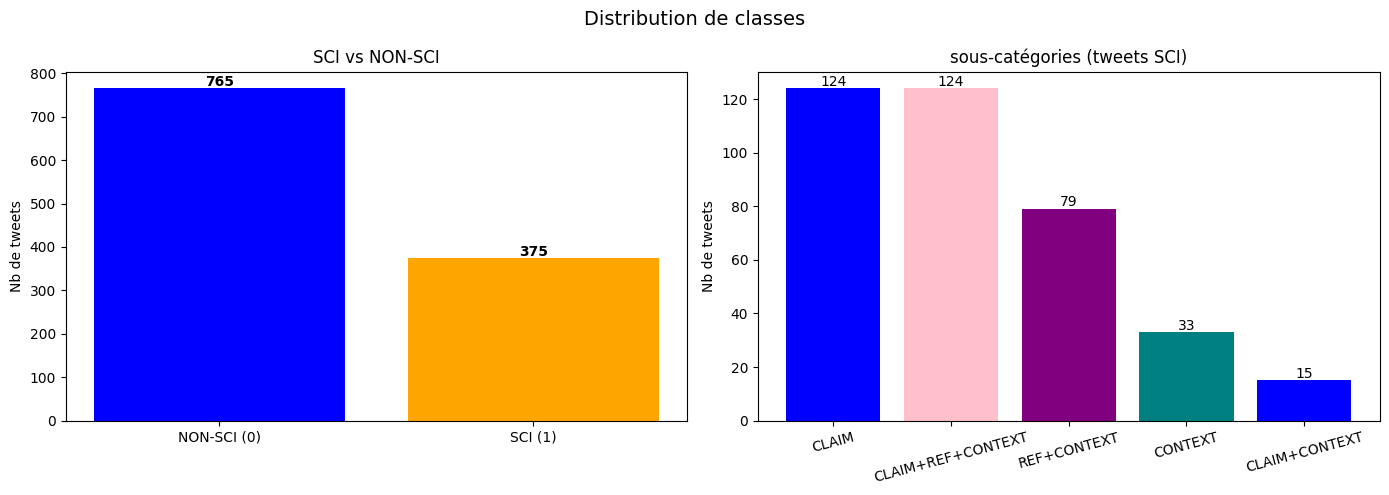

In [3]:
#Distribution des classes
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Distribution de classes", fontsize=14)

counts_sci = df["science_related"].value_counts()
axes[0].bar(
    ["NON-SCI (0)", "SCI (1)"],
    [counts_sci.get(0, 0), counts_sci.get(1, 0)],
    color=["blue", "orange"]
)
axes[0].set_title("SCI vs NON-SCI")
axes[0].set_ylabel("Nb de tweets")
for i, v in enumerate([counts_sci.get(0, 0), counts_sci.get(1, 0)]):
    axes[0].text(i, v + 5, str(v), ha="center", fontweight="bold")

# pour les sous-catégories
df_sci = df[df["science_related"] == 1].copy()

def get_label(row):
    labels = []
    if row["scientific_claim"] == 1:
        labels.append("CLAIM")
    if row["scientific_reference"] == 1:
        labels.append("REF")
    if row["scientific_context"] == 1:
        labels.append("CONTEXT")
    return "+".join(labels) if labels else "UNKNOWN"

df_sci["sublabel"] = df_sci.apply(get_label, axis=1)
sublabel_counts = df_sci["sublabel"].value_counts()

axes[1].bar(sublabel_counts.index, sublabel_counts.values, color=["blue", "pink","purple","teal"])
axes[1].set_title("sous-catégories (tweets SCI)")
axes[1].set_ylabel("Nb de tweets")
axes[1].tick_params(axis="x", rotation=15)
for i, v in enumerate(sublabel_counts.values):
    axes[1].text(i, v + 1, str(v), ha="center")

plt.tight_layout()
plt.show()

On observe un désequilibre dans la répartition, cela demande un modèle plus compliquée vu qu'il serait appris sur 2:1 data

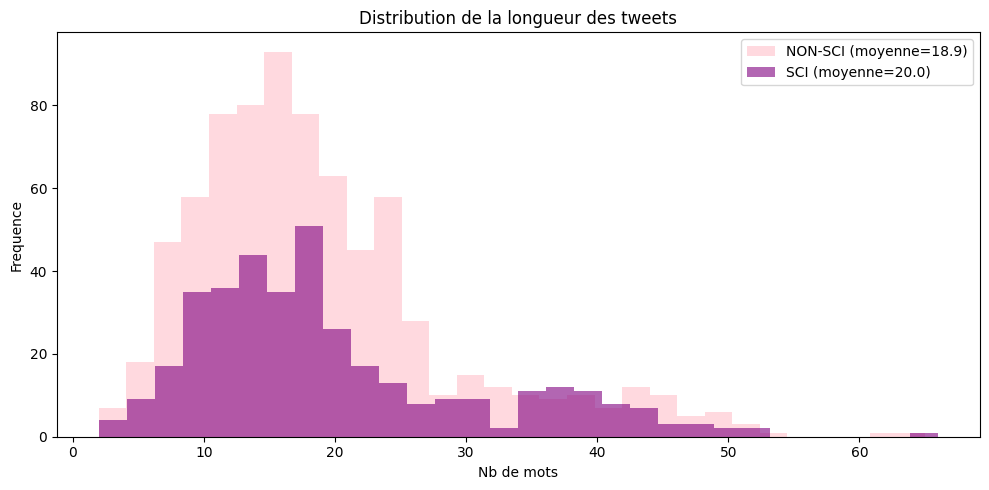

In [4]:
###################################################
# un petit test pour voir si la longueur d'un tweet dit qlq chose sur ça catégorie (sci ou ono-sci)

df["tweet_length"] = df["text"].apply(lambda x: len(str(x).split()))

fig, ax = plt.subplots(figsize=(10, 5))
for label, color, name in [(0, "pink", "NON-SCI"), (1, "purple", "SCI")]:
    subset = df[df["science_related"] == label]["tweet_length"]
    ax.hist(subset, bins=30, alpha=0.6, color=color, label=f"{name} (moyenne={subset.mean():.1f})")

ax.set_title("Distribution de la longueur des tweets")
ax.set_xlabel("Nb de mots")
ax.set_ylabel("Frequence")
ax.legend()
plt.tight_layout()
plt.show()


Les 2 graphes sont presque identique signifiant que cette mesure de longueur de tweets n'est pas utile.

In [5]:
#apparently needed this bc otherwise doesnt show fig2?
import plotly.io as pio
pio.renderers.default = "notebook_connected"
import plotly.graph_objects as go

#ACP ###############################################
vectorizer = TfidfVectorizer(
    max_features=2000,
    stop_words="english"
)
X_tfidf = vectorizer.fit_transform(df["text"])

svd = TruncatedSVD(n_components=50, random_state=42)
X_svd = svd.fit_transform(X_tfidf)

pca = PCA(n_components=3, random_state=42)
X_pca_3d = pca.fit_transform(X_svd)

print(f"Variance expliquée par les 3 composantes PCA : "
      f"{pca.explained_variance_ratio_.sum()*100:.1f}%")
print(f"  PC1: {pca.explained_variance_ratio_[0]*100:.1f}%  "
      f"PC2: {pca.explained_variance_ratio_[1]*100:.1f}%  "
      f"PC3: {pca.explained_variance_ratio_[2]*100:.1f}%")

color_task1 = df["science_related"].map({0: "NON-SCI", 1: "SCI"})

df_pca = pd.DataFrame({
    "PC1": X_pca_3d[:, 0],
    "PC2": X_pca_3d[:, 1],
    "PC3": X_pca_3d[:, 2],
    "Tache1": color_task1,
})

fig = make_subplots(
    rows=1, cols=2,
    specs=[[{"type": "xy"}, {"type": "scene"}]],
    subplot_titles=("Projection 2D (Tâche 1 : SCI vs NON-SCI)",
                    "Projection 3D (Tâche 1 : SCI vs NON-SCI)")
)

color_map = {"NON-SCI": "steelblue", "SCI": "darkorange"}

for label in ["NON-SCI", "SCI"]:
    mask = df_pca["Tache1"] == label
    fig.add_trace(
        go.Scatter(
            x=df_pca.loc[mask, "PC1"],
            y=df_pca.loc[mask, "PC2"],
            mode="markers",
            name=label,
            marker=dict(color=color_map[label], size=5, opacity=0.6)
        ),
        row=1, col=1
    )
    fig.add_trace(
        go.Scatter3d(
            x=df_pca.loc[mask, "PC1"],
            y=df_pca.loc[mask, "PC2"],
            z=df_pca.loc[mask, "PC3"],
            mode="markers",
            name=label,
            showlegend=False,
            marker=dict(color=color_map[label], size=3, opacity=0.6)
        ),
        row=1, col=2
    )

fig.update_layout(
    title="ACP des tweets - Level 1",
    width=1000, height=480
)
fig.show()


mask_sci = df["science_related"] == 1
df_pca_sci = df_pca[mask_sci].copy()
df_pca_sci["sublabel"] = df_sci["sublabel"].values

fig2 = make_subplots(
    rows=1, cols=2,
    specs=[[{"type": "xy"}, {"type": "scene"}]],
    subplot_titles=("Projection 2D (Level 2 : sous-catégories)",
                    "Projection 3D (Level 2 : sous-catégories)")
)

colors_sub = px.colors.qualitative.Set2
unique_labels = df_pca_sci["sublabel"].unique()

for i, label in enumerate(unique_labels):
    mask = df_pca_sci["sublabel"] == label
    color = colors_sub[i % len(colors_sub)]
    fig2.add_trace(
        go.Scatter(
            x=df_pca_sci.loc[mask, "PC1"],
            y=df_pca_sci.loc[mask, "PC2"],
            mode="markers",
            name=label,
            marker=dict(color=color, size=5, opacity=0.7)
        ),
        row=1, col=1
    )
    fig2.add_trace(
        go.Scatter3d(
            x=df_pca_sci.loc[mask, "PC1"],
            y=df_pca_sci.loc[mask, "PC2"],
            z=df_pca_sci.loc[mask, "PC3"],
            mode="markers",
            name=label,
            showlegend=False,
            marker=dict(color=color, size=3, opacity=0.7)
        ),
        row=1, col=2
    )

fig2.update_layout(
    title="ACP des tweets - Lvel 2",
    width=1000, height=480
)
fig2.show()


Variance expliquée par les 3 composantes PCA : 17.5%
  PC1: 7.5%  PC2: 5.8%  PC3: 4.2%


Les classes sont très mélangées, on observe aucune séparation linéaire clair.

# 4. Ingenierie de Données

In [6]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()
def get_wordnet(tag):
    if tag.startswith('J'): return wordnet.ADJ
    if tag.startswith('V'): return wordnet.VERB
    if tag.startswith('N'): return wordnet.NOUN
    if tag.startswith('R'): return wordnet.ADV
    return wordnet.NOUN

contractions_map = {
    "don't": "do not",
    "doesn't": "does not",
    "can't": "cannot",
    "won't": "will not",
    "i'm": "i am",
    "it's": "it is",
    "you're": "you are",
    "they're": "they are",
    "we're": "we are",
    "that's": "that is",
}
def expand_contractions(text):
    # Normalisation simple des apostrophes typographiques
    text = text.replace("’", "'")
    tokens = text.split()
    expanded = []
    for t in tokens:
        key = t.lower()
        if key in contractions_map:
            expanded.extend(contractions_map[key].split())
        else:
            expanded.append(t)
    return " ".join(expanded)
    
    
def preprocess(text):
    text = expand_contractions(text)
    text = str(text).lower()

    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'\bhttp\w+\b', '', text)
    text = re.sub(r'@\w+','',text)
    text = re.sub(r'#(\w+)', r'\1', text)
    text = emoji.demojize(text, delimiters=(" ", " "))
    text = text.replace("_", " ")
    text = re.sub(r'[^\w\s]', '', text)
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]
    tags = nltk.pos_tag(tokens)
    tokens = [
        lemmatizer.lemmatize(word, get_wordnet(tag))
        for word, tag in tags
    ]
    
    return " ".join(tokens)


In [7]:
df["text_clean"] = df["text"].apply(preprocess)

for i in range(3):
    print("BEFORE:", df["text"].iloc[i])
    print("AFTER: ", df["text_clean"].iloc[i])
    print()

BEFORE: Knees are a bit sore. i guess that's a sign that my recent treadmilling is working
AFTER:  knee bite sore guess sign recent treadmilling work

BEFORE: McDonald's breakfast stop then the gym 🏀💪
AFTER:  mcdonalds breakfast stop gym basketball flex biceps

BEFORE: Can any Gynecologist with Cancer Experience explain the dangers of Transvaginal Douching with Fluoride or other toxins such as Dioxin? #PDX
AFTER:  gynecologist cancer experience explain danger transvaginal douche fluoride toxin dioxin pdx



In [8]:
#wth are these tweets actually 😭

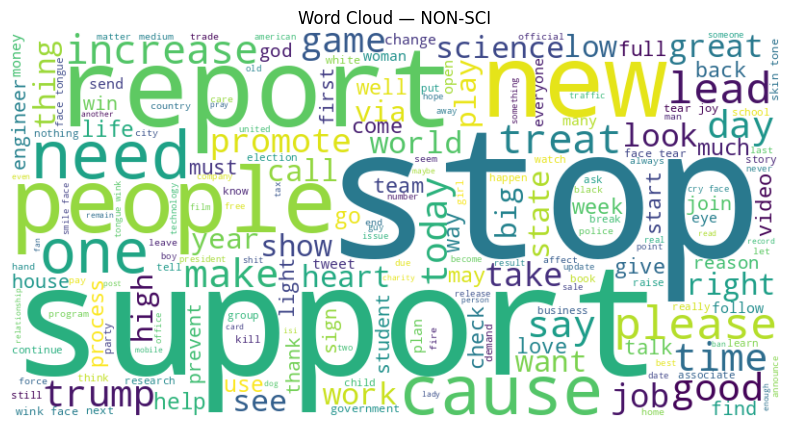

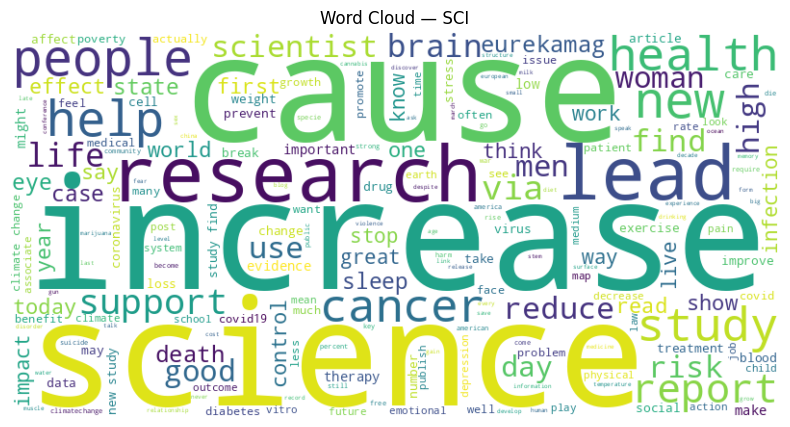

In [9]:
for label, name in [(0, "NON-SCI"), (1, "SCI")]:
    texts = " ".join(df[df["science_related"] == label]["text_clean"])
    wc = WordCloud(width=800, height=400, background_color="white")
    wc.generate(texts)
    plt.figure(figsize=(12, 5))
    plt.title(f"Word Cloud — {name}")
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.show()
#wtvv it doesnt work

# 5. Vectorisation des Documents via TfidfVectorizer

Le but de la vectorisation est de transformer chaque document en vecteur afin d’obtenir une matrice utilisable
comme variables prédictives.
Note : Une limite importante de ces approches est l’absence d’information sur l’ordre des mots. Les n-grammes
peuvent réduire ce problème, mais dès que la structure d’une phrase devient importante, il faut se tourner
vers d’autres méthodes, comme celles utilisées dans les modèles plus récents (LSTM, Transformers, etc.).

In [10]:
# Initialisation du vecteur TF-IDF
vectorizer = TfidfVectorizer(
    stop_words='english', # Stopwords anglais
    max_features=2000, # Limiter à 2000 tokens au total
    token_pattern=r'[a-zA-Z]{2,}' #added because i had numbers 
)
# fit + transform
X = vectorizer.fit_transform(df['text_clean'])
# Affichage sous forme de DataFrame
df_tfidf = pd.DataFrame(
data=X.toarray(),
columns=vectorizer.get_feature_names_out()
)
print(df_tfidf)

      aap  ability  able  abortion  abuse  academic  academy  accept  accord  \
0     0.0      0.0   0.0       0.0    0.0       0.0      0.0     0.0     0.0   
1     0.0      0.0   0.0       0.0    0.0       0.0      0.0     0.0     0.0   
2     0.0      0.0   0.0       0.0    0.0       0.0      0.0     0.0     0.0   
3     0.0      0.0   0.0       0.0    0.0       0.0      0.0     0.0     0.0   
4     0.0      0.0   0.0       0.0    0.0       0.0      0.0     0.0     0.0   
...   ...      ...   ...       ...    ...       ...      ...     ...     ...   
1135  0.0      0.0   0.0       0.0    0.0       0.0      0.0     0.0     0.0   
1136  0.0      0.0   0.0       0.0    0.0       0.0      0.0     0.0     0.0   
1137  0.0      0.0   0.0       0.0    0.0       0.0      0.0     0.0     0.0   
1138  0.0      0.0   0.0       0.0    0.0       0.0      0.0     0.0     0.0   
1139  0.0      0.0   0.0       0.0    0.0       0.0      0.0     0.0     0.0   

      account  ...  year  yes  yesterda

In [11]:
#hmmm a few weird words there but we'll keep it

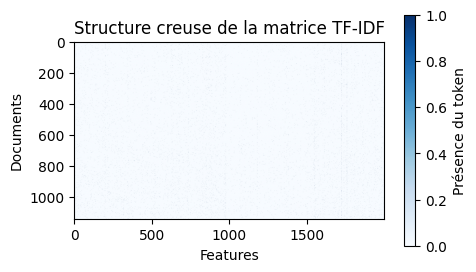

In [12]:
M_tfidf = X.toarray()
plt.figure(figsize=(5, 3))
plt.imshow(M_tfidf > 0, cmap="Blues") # bleu = valeur non nulle, gris = zéro
plt.title("Structure creuse de la matrice TF-IDF")
plt.xlabel("Features")
plt.ylabel("Documents")
plt.colorbar(label="Présence du token")
plt.show()

In [13]:
#well that looks useless, but it makes sense as tweets are short and for 2000 features most of it would be zero

In [14]:
features = vectorizer.get_feature_names_out()
print(f"features: {features[:20]} \n")

means = X.mean(axis=0).A1  #A1 flattens the matrix
topT = means.argsort()[::-1][:20]
print("top 20 tokens by tf-idf mean score")
for i in topT:
    print(f"  {features[i]:<20} {means[i]:.4f}")

features: ['aap' 'ability' 'able' 'abortion' 'abuse' 'academic' 'academy' 'accept'
 'accord' 'account' 'accuse' 'achievement' 'act' 'action' 'activist'
 'activity' 'actually' 'ad' 'add' 'additional'] 

top 20 tokens by tf-idf mean score
  stop                 0.0355
  support              0.0273
  report               0.0176
  cause                0.0151
  people               0.0144
  new                  0.0129
  science              0.0114
  lead                 0.0111
  increase             0.0111
  face                 0.0110
  good                 0.0097
  study                0.0095
  need                 0.0091
  life                 0.0081
  research             0.0081
  like                 0.0080
  help                 0.0076
  change               0.0073
  day                  0.0073
  world                0.0072


# 6. Classification Tache 1 : SCI vs NON-SCI

In [15]:
pipeline = Pipeline([
    ("vectorizer", TfidfVectorizer(
        ngram_range=(1, 2),
        preprocessor= preprocess, 
        #stop_words='english',
        max_features=2000,
        token_pattern=r'\b(?!http)\w{3,}\b',
        min_df=3,
        max_df=0.8
    )),
    ("clf", SVC(kernel="linear")) #for now we are sticking t SVM but we'll compare with other classifiers
])

X = df["text"]
y = df["science_related"]

In [16]:
validation_size = 0.3 # 30 % du jeu de données pour le test
seed = 30
X_train, X_test, y_train, y_test = train_test_split(
X, y,
test_size=validation_size,
random_state=seed
)
print ("Format du jeu d'apprentissage : ",X_train.shape)
print ("Format du jeu de test :", X_test.shape)

Format du jeu d'apprentissage :  (798,)
Format du jeu de test : (342,)


In [17]:
pipeline.fit(X_train, y_train)
print("Accuracy:", pipeline.score(X_test, y_test))
y_pred = pipeline.predict(X_test)
conf = confusion_matrix(y_test, y_pred)
print("\nMatrice de confusion\n", conf)
print("\nClassification report\n",
classification_report(y_test, y_pred))

Accuracy: 0.8070175438596491

Matrice de confusion
 [[215  18]
 [ 48  61]]

Classification report
               precision    recall  f1-score   support

           0       0.82      0.92      0.87       233
           1       0.77      0.56      0.65       109

    accuracy                           0.81       342
   macro avg       0.79      0.74      0.76       342
weighted avg       0.80      0.81      0.80       342



### Remarques : 
tandis que l'accuracy est 80%, l'apprentissage montre un deséquilibre entre les classes, le modele favorise la classe 0 (recall=0.91)
la matrice de confusion le montre aussi avec 50 SCI "misclassified as NON-SCI" contre 20 NON-SCI misclassified as SCI 
on peut résumé cela on disons que notre modèle classifie bien les tweets comme NON-SCI mais inutile pour les classifié comme SCI et cela est un résultat du deséquilibre de répartition des classes (765 pour classe 0 et 375 pour classe 1) 

In [18]:
pipeline.set_params(clf=SVC(kernel="linear", class_weight="balanced"))

Pipeline(steps=[('vectorizer',
                 TfidfVectorizer(max_df=0.8, max_features=2000, min_df=3,
                                 ngram_range=(1, 2),
                                 preprocessor=<function preprocess at 0x7950ac2eff40>,
                                 token_pattern='\\b(?!http)\\w{3,}\\b')),
                ('clf', SVC(class_weight='balanced', kernel='linear'))])

In [19]:
kfold = KFold(n_splits=10, shuffle=True, random_state=42)
#scores = cross_val_score(pipeline, X, y, cv=kfold, scoring="f1")
scores = cross_val_score(pipeline, df['text_clean'], y, cv=kfold, scoring="f1")
print(f"F1 moyen: {scores.mean():.3f} ± {scores.std():.3f}")

F1 moyen: 0.676 ± 0.056


## Comparaison avec d'autres classifieurs

In [20]:
kfold = KFold(n_splits=10, shuffle=True, random_state=42)
X_clean = df["text_clean"]

models = [
    ("SVM linear (baseline)",   SVC(kernel="linear")),
    ("SVM linear (balanced)",   SVC(kernel="linear", class_weight="balanced")),
    ("SVM RBF (balanced)",      SVC(kernel="rbf", class_weight="balanced")),
    ("Logistic Regression",     LogisticRegression(class_weight="balanced", max_iter=1000)),
    ("Random Forest",           RandomForestClassifier(class_weight="balanced", random_state=42)),
    ("Decision Tree",           DecisionTreeClassifier(class_weight="balanced", random_state=42)),
    ("Naive Bayes",             MultinomialNB()),
    ("KNN",                     KNeighborsClassifier()),
]

print(f"{'Model':<30} {'F1 mean':>10} {'F1 std':>10} {'Acc mean':>10}")
print("-" * 64)

results = []
for name, clf in models:
    pipe = Pipeline([
        ("tfidf", TfidfVectorizer(
            ngram_range=(1, 2),
            max_features=3000,
            token_pattern=r'\b(?!http)\w{3,}\b',
            min_df=3,
            max_df=0.8
        )),
        ("clf", clf)
    ])
    #f1 = cross_val_score(pipe, X, y, cv=kfold, scoring="f1")
    f1 = cross_val_score(pipe, df['text_clean'], y, cv=kfold, scoring="f1")
    #acc = cross_val_score(pipe, X, y, cv=kfold, scoring="accuracy")
    acc = cross_val_score(pipe, df['text_clean'], y, cv=kfold, scoring="accuracy")

    results.append((name, f1.mean(), f1.std(), acc.mean()))
    print(f"{name:<30} {f1.mean():>10.3f} {f1.std():>10.3f} {acc.mean():>10.3f}")

Model                             F1 mean     F1 std   Acc mean
----------------------------------------------------------------
SVM linear (baseline)               0.640      0.067      0.793
SVM linear (balanced)               0.676      0.056      0.779
SVM RBF (balanced)                  0.693      0.066      0.805
Logistic Regression                 0.691      0.069      0.787
Random Forest                       0.661      0.055      0.773
Decision Tree                       0.609      0.062      0.725
Naive Bayes                         0.599      0.058      0.798
KNN                                 0.505      0.039      0.382


In [21]:
# On remarque Logistic Regression présente les meilleur résultats suivi par SVM RBF pour les prochaines comparaison nous avons choisie de continuzr
#avec Logistic Regression 

### Comparaison avec StartifiedKFold

In [22]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
results = []
X_clean = df['text_clean']
y = df['science_related']

for name, clf in models:
    pipe = Pipeline([
        ("tfidf", TfidfVectorizer(
            ngram_range=(1, 2),
            max_features=3000,
            token_pattern=r'\b(?!http)\w{3,}\b',
            min_df=3,
            max_df=0.8
        )),
        ("clf", clf)
    ])
    scores = cross_validate(pipe, X_clean, y, cv=cv, scoring=['f1', 'precision', 'recall', 'accuracy'], n_jobs=-1)
    results.append({
        'Modèle': name,
        'F1': scores['test_f1'].mean(),
        'F1 std': scores['test_f1'].std(),
        'Précision': scores['test_precision'].mean(),
        'Rappel': scores['test_recall'].mean(),
        'Accuracy': scores['test_accuracy'].mean(),
    })

df_results = pd.DataFrame(results).sort_values('F1', ascending=False).reset_index(drop=True)
print("\n Meilleur modèle:", df_results.iloc[0]['Modèle'], 
      f"(F1={df_results.iloc[0]['F1']:.3f})")


 Meilleur modèle: Logistic Regression (F1=0.700)


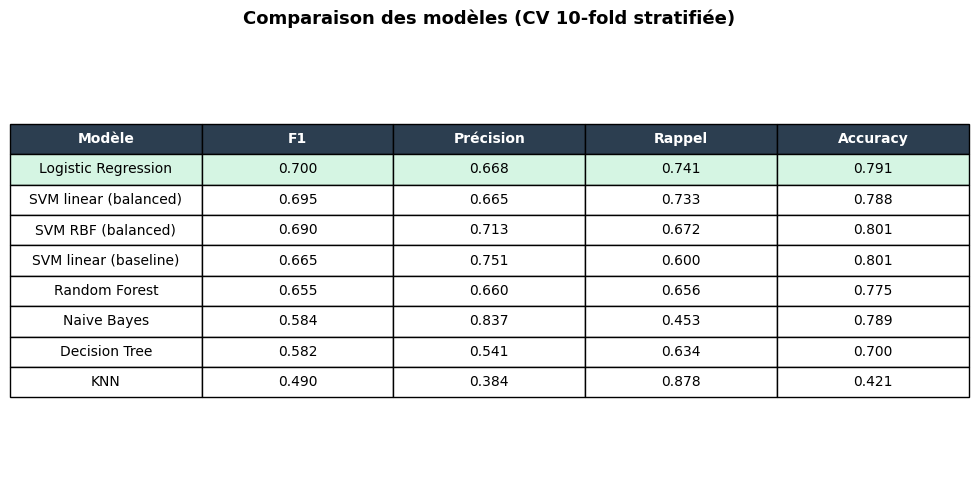

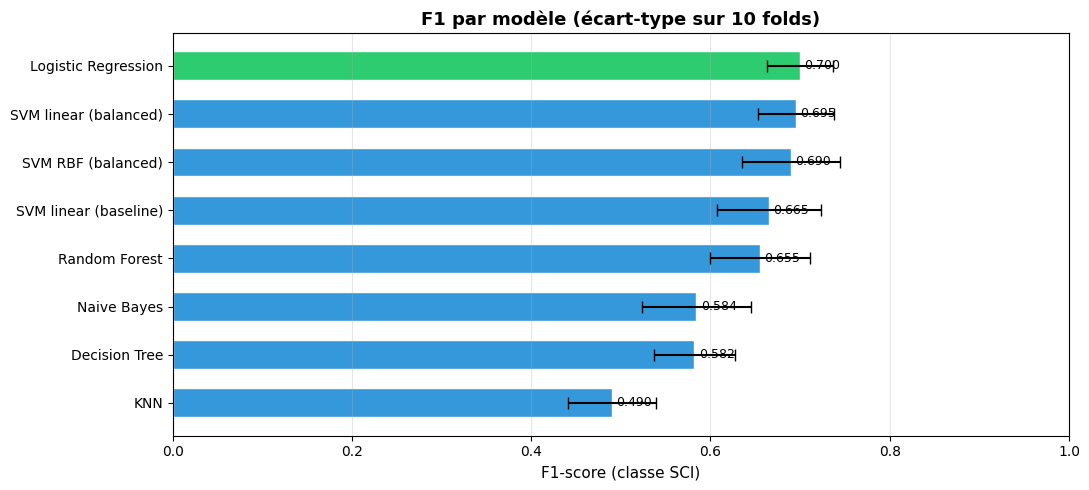

In [24]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.axis('off')
cols_display = ['Modèle', 'F1', 'Précision', 'Rappel', 'Accuracy']
table_data = df_results[cols_display].copy()
for c in cols_display[1:]:
    table_data[c] = table_data[c].map('{:.3f}'.format)

tbl = ax.table(cellText=table_data.values, colLabels=cols_display, loc='center', cellLoc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.3, 1.6)

for j in range(len(cols_display)):
    tbl[0, j].set_facecolor('#2c3e50')
    tbl[0, j].set_text_props(color='white', fontweight='bold')

for j in range(len(cols_display)):
    tbl[1, j].set_facecolor('#d5f5e3')

plt.title('Comparaison des modèles (CV 10-fold stratifiée)', fontsize=13, pad=12, fontweight='bold')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(11, 5))
colors = ['#2ecc71' if i == 0 else '#3498db' for i in range(len(df_results))]
bars = ax.barh(df_results['Modèle'][::-1], df_results['F1'][::-1], 
               xerr=df_results['F1 std'][::-1], color=colors[::-1], 
               edgecolor='white', capsize=4, height=0.6)

for bar, val in zip(bars, df_results['F1'][::-1]):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center', fontsize=9)

ax.set_xlabel('F1-score (classe SCI)', fontsize=11)
ax.set_title('F1 par modèle (écart-type sur 10 folds)', fontsize=13, fontweight='bold')
ax.set_xlim(0, 1.0)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## Interprétation des résultats

- **Meilleur modèle** : Logistic Regression (F1 = 0,700) meilleur compromis précision/rappel.
- **SVM linéaire balanced** très proche (F1 = 0,695), mais la régression logistique est plus simple et plus interprétable.
- **SVM RBF** stable mais légèrement moins performant.
- **Naive Bayes et Decision Tree** le premier sous-détecte la classe SCI, le second sur-apprend.
- **KNN** est inutilisable ici (précision très faible).

Le déséquilibre des classes (≈2:1 NON‑SCI/SCI) explique pourquoi les modèles avec class_weight='balanced' (LR, SVM linear/RBF) surpassent nettement leur version baseline.

## Comparaison de configurations TF-IDF

In [23]:
experiments = [
    ("unigrams",     df["text"],       TfidfVectorizer(max_features=2000, min_df=3, max_df=0.8)),
    ("bigrams",      df["text"],       TfidfVectorizer(ngram_range=(1,2), max_features=3000, min_df=3, max_df=0.8)),
    ("text_clean",   df["text_clean"], TfidfVectorizer(max_features=2000, min_df=3, max_df=0.8)),
    ("5000 features",df["text"],       TfidfVectorizer(max_features=5000, min_df=3, max_df=0.8)),
    ("bigrams + 5000 features",df["text"],       TfidfVectorizer(max_features=5000, min_df=3, max_df=0.8)),
    ("text_clean + bigrams",   df["text_clean"], TfidfVectorizer(ngram_range=(1,2), max_features=2000, min_df=3, max_df=0.8)),
    ("text_clean + 5000 f",   df["text_clean"], TfidfVectorizer(ngram_range=(1,2), max_features=5000, min_df=3, max_df=0.8)),
    ("text_clean + bigrams + 5000f",   df["text_clean"], TfidfVectorizer(ngram_range=(1,2), max_features=5000, min_df=3, max_df=0.8)),
]

clf = LogisticRegression(class_weight="balanced", max_iter=1000)

print(f"{'Experiment':<35} {'F1 mean':>10} {'F1 std':>10}")
print("-" * 55)
for name, X_exp, vectorizer in experiments:
    pipe = Pipeline([("tfidf", vectorizer), ("clf", clf)])
    f1 = cross_val_score(pipe, X_exp, y, cv=kfold, scoring="f1")
    print(f"{name:<35} {f1.mean():>10.3f} {f1.std():>10.3f}")

Experiment                             F1 mean     F1 std
-------------------------------------------------------
unigrams                                 0.707      0.066
bigrams                                  0.717      0.066
text_clean                               0.691      0.070
5000 features                            0.707      0.066
bigrams + 5000 features                  0.707      0.066
text_clean + bigrams                     0.691      0.070
text_clean + 5000 f                      0.691      0.070
text_clean + bigrams + 5000f             0.691      0.070


**commentaires :** bigrams donne la meilleure F1 moyenne, légèrement supérieure aux autres configs. Cela peut être expliquer par le fait que ces derniers (paires de mots consécutifs) permet de capturer un peu de contexte, ce qui améliore la discrimination entre les classes par rapport aux unigrammes seuls.
Ajouter plus de caractéristiques (5000 features) ou utiliser le texte nettoyé (text_clean) ne semble pas apporter d'amélioration supplémentaire, probablement parce que cela introduit davantage de bruit ou supprime des informations utiles.

## Pipeline Final

In [30]:
def objective(trial):
    C = trial.suggest_float("C", 0.01, 100, log=True)
    max_features = trial.suggest_int("max_features", 1000, 5000, step=500)
    min_df = trial.suggest_int("min_df", 1, 5)
    
    pipe = Pipeline([
        ("tfidf", TfidfVectorizer(
            ngram_range=(1, 2),
            max_features=max_features,
            min_df=min_df,
            max_df=0.8
        )),
        ("clf", LogisticRegression(
            C=C,
            class_weight="balanced",
            max_iter=1000
        ))
    ])
    scores = cross_val_score(pipe, df["text"], y, cv=5, scoring="f1")
    return scores.mean()

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50)

print("Meilleur score Optuna :", study.best_value, "\n")
print("Meilleurs hyperparamètres :")
print(study.best_params)

[I 2026-05-13 20:14:18,562] A new study created in memory with name: no-name-344b5f27-aacb-4375-8494-1bba54c84879
[I 2026-05-13 20:14:18,834] Trial 0 finished with value: 0.6713317532933256 and parameters: {'C': 0.1681522585080202, 'max_features': 1500, 'min_df': 2}. Best is trial 0 with value: 0.6713317532933256.
[I 2026-05-13 20:14:19,222] Trial 1 finished with value: 0.684024966354486 and parameters: {'C': 19.703449475534295, 'max_features': 4500, 'min_df': 4}. Best is trial 1 with value: 0.684024966354486.
[I 2026-05-13 20:14:19,525] Trial 2 finished with value: 0.7006074589867126 and parameters: {'C': 2.976039087144336, 'max_features': 3000, 'min_df': 5}. Best is trial 2 with value: 0.7006074589867126.
[I 2026-05-13 20:14:19,750] Trial 3 finished with value: 0.6408935238203531 and parameters: {'C': 0.02847564296581749, 'max_features': 3000, 'min_df': 2}. Best is trial 2 with value: 0.7006074589867126.
[I 2026-05-13 20:14:19,981] Trial 4 finished with value: 0.6681318113183826 and 

Meilleur score Optuna : 0.7209448680182338 

Meilleurs hyperparamètres :
{'C': 1.418472784722332, 'max_features': 3000, 'min_df': 3}


In [36]:
best_params = study.best_params

pipeline_final = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1, 2),
        max_features=best_params["max_features"],
        min_df=best_params["min_df"],
        max_df=0.8,
        #stop_words="english",
        preprocessor=preprocess
    )),
    ("clf", LogisticRegression(
        C=best_params["C"],
        class_weight="balanced",
        max_iter=1000
    ))
])



In [37]:
scores = cross_val_score(
    pipeline_final,
    df["text"],
    y,
    cv=5,
    scoring="f1"
)

print(f"Final F1: {scores.mean():.3f} ± {scores.std():.3f}")

Final F1: 0.676 ± 0.048


In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    df["text"], y, test_size=0.2, random_state=42
)

pipeline_final.fit(X_train, y_train)
y_pred = pipeline_final.predict(X_test)
#conf = confusion_matrix(y_test, y_pred)
#print("\nMatrice de confusion\n", conf)

#print(classification_report(y_test, y_pred))

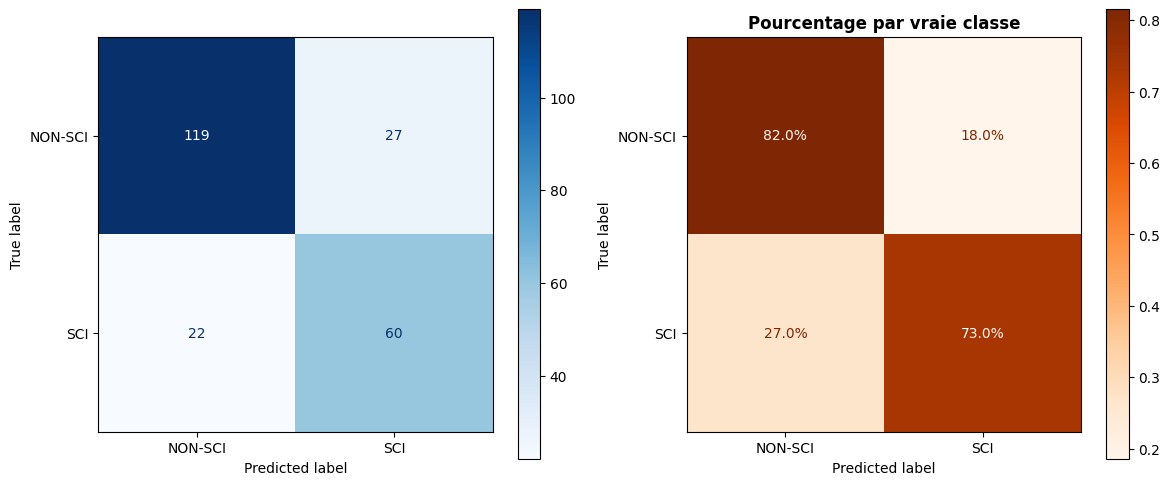

In [39]:
cm = confusion_matrix(y_test, y_pred)
cm_norm = confusion_matrix(y_test, y_pred, normalize='true')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay(cm, display_labels=['NON-SCI', 'SCI']).plot(ax=axes[0], cmap='Blues')

disp2 = ConfusionMatrixDisplay(cm_norm, display_labels=['NON-SCI', 'SCI'])
disp2.plot(ax=axes[1], cmap='Oranges')
for text in axes[1].texts:
    text.set_text(f'{float(text.get_text()):.1%}')
axes[1].set_title('Pourcentage par vraie classe', fontweight='bold')

plt.tight_layout()
plt.show()

# 7. Analyses Des Erreurs

In [40]:
X_raw = df['text']        
X_clean = df['text_clean']  
y = df['science_related']

X_train_raw, X_test_raw, X_train_c, X_test_c, y_train, y_test = train_test_split(
    X_raw, X_clean, y, test_size=0.2, random_state=42, stratify=y
)

pipeline_final.fit(X_train_c, y_train)
y_pred = pipeline_final.predict(X_test_c)

# Affichage des tweets mal classifiés

df_test = pd.DataFrame({
    'text_brut':    X_test_raw.values,
    'text_clean':   X_test_c.values,
    'y_true':       y_test.values,
    'y_pred':       y_pred,
    'score':        pipeline_final.decision_function(X_test_c) 
})
df_test['erreur'] = df_test['y_true'] != df_test['y_pred']

# tweets SCI classés NON-SCI 
faux_negatifs = df_test[(df_test['y_true'] == 1) & (df_test['y_pred'] == 0)]
# tweets NON-SCI classés SCI
faux_positifs = df_test[(df_test['y_true'] == 0) & (df_test['y_pred'] == 1)]

print(f'Nombre de faux négatifs  : {len(faux_negatifs)}')
print(f'Nombre de faux positifs : {len(faux_positifs)}')
print()

# trier pae score, plus il est proche au seuil plus l'erreur is weird
fn_sorted = faux_negatifs.sort_values('score', ascending=False).head(10)
fp_sorted = faux_positifs.sort_values('score', ascending=True).head(10)

print('=' * 80)
print('FAUX NÉGATIFS : tweets SCI classés NON-SCI')
print('(score proche de 0 = le modèle hésitait ; score très négatif = erreur franche)')
print('=' * 80)
for i, (_, row) in enumerate(fn_sorted.iterrows(), 1):
    print(f"\n[FN {i}] Score = {row['score']:.3f}")
    print(f"  Texte : {row['text_brut'][:300]}")

print()
print('=' * 80)
print('FAUX POSITIFS : tweets NON-SCI classés SCI')
print('=' * 80)
for i, (_, row) in enumerate(fp_sorted.iterrows(), 1):
    print(f"\n[FP {i}] Score = {row['score']:.3f}")
    print(f"  Texte : {row['text_brut'][:300]}")

Nombre de faux négatifs  : 17
Nombre de faux positifs : 24

FAUX NÉGATIFS : tweets SCI classés NON-SCI
(score proche de 0 = le modèle hésitait ; score très négatif = erreur franche)

[FN 1] Score = -0.024
  Texte : States herself trauma causes norepinephrine to imprint memories on the hippocampus. Yet, can't remember anything. #ConfirmKavanaughNow https://t.co/pm2XhJOOeb

[FN 2] Score = -0.041
  Texte : Weed: Good for the Bones? YES! by Stephanie Pappas, Live Science Contributor http://t.co/L4pERvnmmo http://t.co/pPBGZwZLBG

[FN 3] Score = -0.086
  Texte : It's not your fitness tracker -- it's you https://t.co/HXZUORH9Yc https://t.co/C2gFbkiGR2

[FN 4] Score = -0.086
  Texte : Discuss. https://t.co/dCbMs4MjB6

[FN 5] Score = -0.093
  Texte : @cambecc @fhuysmans @steltenpower The visualization is tremendous! But I wouldn't compare one day to another. The long-term trends are a bit more nuanced, and the data doesn't necessarily reflect what is being reported by a lot of media https://t.c

## Remarques

1. **Les faux négatifs** concernent principalement des tweets scientifiques rédigés dans un style informel, très courts (parfois juste un lien) ou noyé avec des mentions. Le modèle ne détecte pas le vocabulaire scientifique typique (`study`, `research`, `data`).

2. **Les faux positifs** s'expliquent par la présence de termes scientifiques (`climate`, `Ebola`, `confidence`) dans des contextes non scientifiques (politique, activisme, ...ect).

Ces erreurs montrent les limites d'une approche purement lexicale (TF‑IDF + régression logistique). Une amélioration possible serait d'utiliser des modèles contextuels (BERT) ou d'ajouter des règles post‑traitement pour détecter les controverses et les citations.

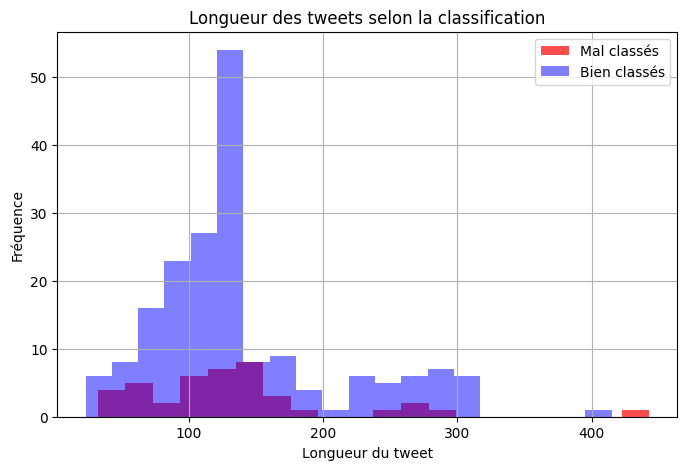

In [41]:
df_test['longueur'] = df_test['text_brut'].str.len()

fig, ax = plt.subplots(figsize=(8, 5))
df_test[df_test['erreur'] == True]['longueur'].hist(bins=20, alpha=0.7, color='red', label='Mal classés')
df_test[df_test['erreur'] == False]['longueur'].hist(bins=20, alpha=0.5, color='blue', label='Bien classés')
ax.set_xlabel('Longueur du tweet')
ax.set_ylabel('Fréquence')
ax.legend()
ax.set_title('Longueur des tweets selon la classification')
plt.show()

# 8. BONUS : Liste de features discriminantes

extraction des mots/bigrammes les plus discriminant pour séparer SCI de NON-SCI. pour cela on utilise le coefficient de Lgoc Regression (LR)

In [48]:
# Vectoriser
tfidf_bonus =  TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=best_params["max_features"],
    min_df=best_params["min_df"],
    max_df=0.8,
    preprocessor=preprocess
)

X_bonus = tfidf_bonus.fit_transform(df['text'])
y_bonus = df['science_related']
feature_names = np.array(tfidf_bonus.get_feature_names_out())

# LR
lr_bonus = LogisticRegression(class_weight='balanced', max_iter=1000,
                               C=pipeline_final.named_steps['clf'].C)
lr_bonus.fit(X_bonus, y_bonus)

LogisticRegression(C=1.418472784722332, class_weight='balanced', max_iter=1000)

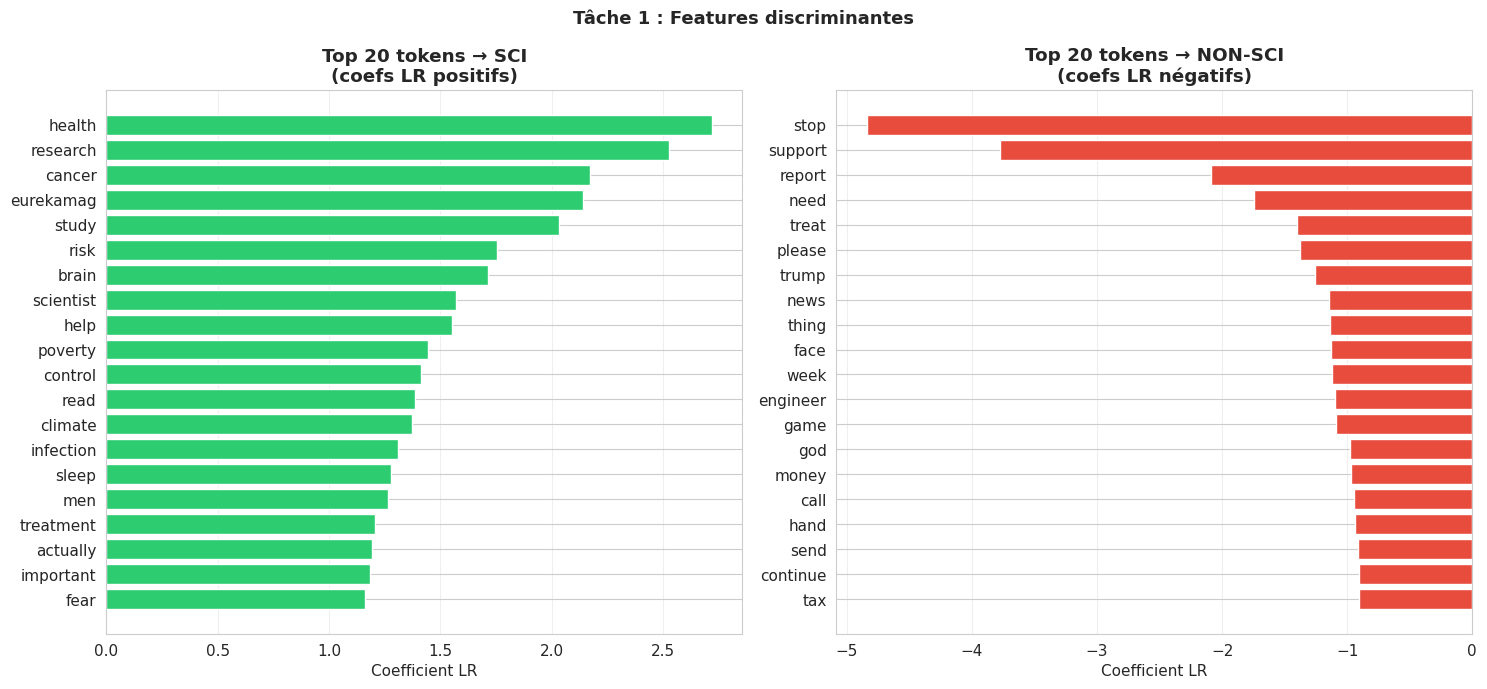

Top 20 features SCI :
    token     coef
   health 2.719442
 research 2.525393
   cancer 2.174098
eurekamag 2.140305
    study 2.031202
     risk 1.756235
    brain 1.716102
scientist 1.570208
     help 1.551655
  poverty 1.442591
  control 1.412675
     read 1.388525
  climate 1.371521
infection 1.308081
    sleep 1.278867
      men 1.267258
treatment 1.204902
 actually 1.192083
important 1.184708
     fear 1.162890

Top 20 features NON-SCI :
   token      coef
    stop -4.842258
 support -3.775647
  report -2.089796
    need -1.744861
   treat -1.402616
  please -1.380955
   trump -1.259485
    news -1.142587
   thing -1.135482
    face -1.130724
    week -1.122026
engineer -1.094242
    game -1.085477
     god -0.974662
   money -0.965727
    call -0.944724
    hand -0.937233
    send -0.913399
continue -0.904989
     tax -0.904162


In [49]:
TOP_N = 20
coefs = lr_bonus.coef_[0]

#features
top_sci_idx  = coefs.argsort()[::-1][:TOP_N] #positives
top_nonsci_idx = coefs.argsort()[:TOP_N] #negatives

df_coefs_sci    = pd.DataFrame({'token': feature_names[top_sci_idx],
                                 'coef':  coefs[top_sci_idx]})
df_coefs_nonsci = pd.DataFrame({'token': feature_names[top_nonsci_idx],
                                 'coef':  coefs[top_nonsci_idx]})

fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# SCI
axes[0].barh(df_coefs_sci['token'][::-1], df_coefs_sci['coef'][::-1],
             color='#2ecc71', edgecolor='white')
axes[0].set_title(f'Top {TOP_N} tokens → SCI\n(coefs LR positifs)', fontweight='bold')
axes[0].set_xlabel('Coefficient LR')
axes[0].grid(axis='x', alpha=0.3)

# NON-SCI
axes[1].barh(df_coefs_nonsci['token'][::-1], df_coefs_nonsci['coef'][::-1],
             color='#e74c3c', edgecolor='white')
axes[1].set_title(f'Top {TOP_N} tokens → NON-SCI\n(coefs LR négatifs)', fontweight='bold')
axes[1].set_xlabel('Coefficient LR')
axes[1].grid(axis='x', alpha=0.3)

plt.suptitle('Tâche 1 : Features discriminantes',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Top 20 features SCI :')
print(df_coefs_sci.to_string(index=False))
print()
print('Top 20 features NON-SCI :')
print(df_coefs_nonsci.to_string(index=False))

## Tâche 1 : Analyse des features discriminantes

**Pour la classe SCI** : les mots les plus discriminants sont `health` (2.72), `research` (2.54), `cancer` (2.17), et `study` (2.02). On observe une dominance du vocabulaire médical, académique et méthodologique (`control, risk`).

**Pour la classe NON-SCI** : les mots les plus discriminants sont `stop` (-4.82), `support` (-3.75), `report` (-2.07), et `need` (-1.66). Ils reflètent des actions sociales, des opinions politiques (`trump, news`), et des expressions du quotidien.

**Cas d'ambiguïté** : certains mots apparaîssent dans un coté mais peuvent également être dans l'autre.

# Tâche 2 : Classification Claim + ref VS Context 

In [136]:
print(df_sci[["scientific_claim", "scientific_reference", "scientific_context"]].sum())
df_sci[
    (df_sci["scientific_claim"] == 1) &
    (df_sci["scientific_reference"] == 1)
]

scientific_claim        263.0
scientific_reference    203.0
scientific_context      251.0
dtype: float64


,Unnamed: 0,tweet_id,text,science_related,scientific_claim,scientific_reference,scientific_context,sublabel,target,CLAIM,REF,CONTEXT
6,8,333266791960809472,“Traffic Jam” In Brain’s Neurons Could Be Caus...,1,1.0,1.0,1.0,CLAIM+REF+CONTEXT,1,1,1,1
40,44,375599373771898880,Sleep 'boosts brain cell numbers' http://t.co/...,1,1.0,1.0,1.0,CLAIM+REF+CONTEXT,1,1,1,1
43,47,378087292306337792,Versatile microRNAs Choke Off Cancer Blood Sup...,1,1.0,1.0,1.0,CLAIM+REF+CONTEXT,1,1,1,1
59,66,402844901475618816,#Multiple #Births Cost Significantly More Than...,1,1.0,1.0,1.0,CLAIM+REF+CONTEXT,1,1,1,1
66,74,411247736525434880,"Europa, a moon of Jupiter has a gigantic ocean...",1,1.0,1.0,1.0,CLAIM+REF+CONTEXT,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
1119,1237,1326505338338729985,The lack of a monetary price for the negative ...,1,1.0,1.0,1.0,CLAIM+REF+CONTEXT,1,1,1,1
1120,1238,1326974458939191297,"Despite the risks associated with their use, #...",1,1.0,1.0,1.0,CLAIM+REF+CONTEXT,1,1,1,1
1122,1240,1333513320159186944,@harwood_su None of the trials currently under...,1,1.0,1.0,1.0,CLAIM+REF+CONTEXT,1,1,1,1
1125,1243,1334539147579707392,Tightly woven blood vessels in solid tumors ca...,1,1.0,1.0,1.0,CLAIM+REF+CONTEXT,1,1,1,1


In [46]:
df_sci["target"] = df_sci["sublabel"].apply(
    lambda x: 1 if "CLAIM" in x or "REF" in x else 0
)
print(df_sci["target"])
print(df_sci["text"])
# a graph would be better maybe but this is jsut to show how many we have 
counts = df_sci["target"].value_counts()
print(counts)

2       1
3       1
4       1
6       1
7       1
       ..
1128    1
1130    0
1131    0
1134    1
1135    1
Name: target, Length: 375, dtype: int64
2       Can any Gynecologist with Cancer Experience ex...
3       Couch-lock highs lead to sleeping in the couch...
4       Does daily routine help prevent problems with ...
6       “Traffic Jam” In Brain’s Neurons Could Be Caus...
7       Can playing more games improve lives and save ...
                              ...                        
1128    Three systematic reviews & the WHO contradict ...
1130    This looks like a great opportunity to get res...
1131    Highly prestigious and competitive awards fund...
1134    Vestislav Apostolov, David M. J. Calderbank, E...
1135    @LaylaFanucci @realDonaldTrump I'm sorry but w...
Name: text, Length: 375, dtype: object
target
1    342
0     33
Name: count, dtype: int64


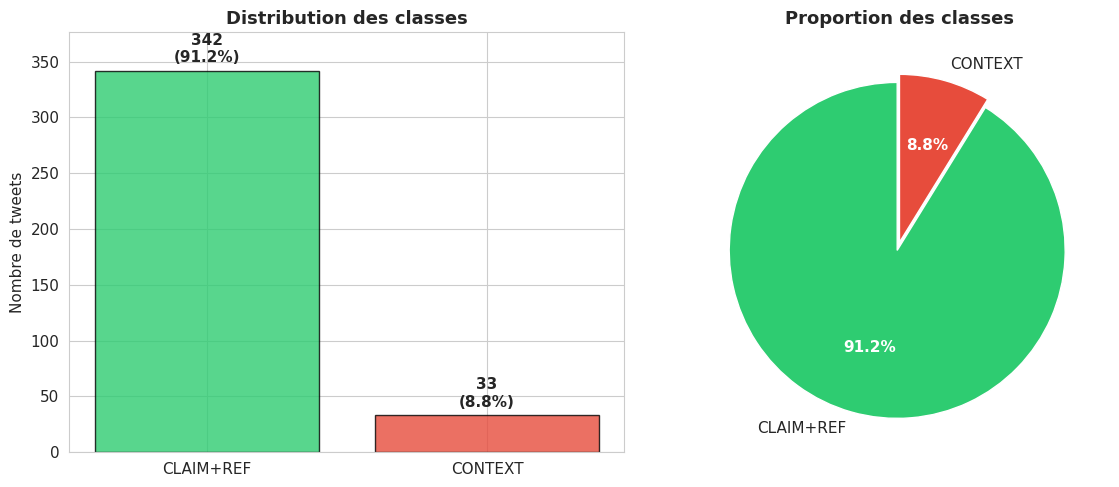

RÉPARTITION DES CLASSES
CLAIM+REF : 342 tweets (91.2%)
CONTEXT : 33 tweets (8.8%)
Total : 375 tweets


In [57]:
sns.set_style("whitegrid")
plt.rcParams['font.size'] = 11

# Données
counts = df_sci["target"].value_counts()
labels = ['CLAIM+REF', 'CONTEXT']

# Graphe
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Barplot
colors = ['#2ecc71', '#e74c3c']
bars = axes[0].bar(labels, counts.values, color=colors, edgecolor='black', alpha=0.8)
axes[0].set_title('Distribution des classes', fontweight='bold', fontsize=13)
axes[0].set_ylabel('Nombre de tweets')
axes[0].set_ylim(0, max(counts.values) * 1.1)

for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, 
                 f'{val}\n({val/len(df_sci)*100:.1f}%)', 
                 ha='center', va='bottom', fontweight='bold')

# Pie chart 
wedges, texts, autotexts = axes[1].pie(counts.values, 
                                        labels=labels, 
                                        autopct='%1.1f%%',
                                        colors=colors,
                                        explode=(0.05, 0),
                                        startangle=90)
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
axes[1].set_title('Proportion des classes', fontweight='bold', fontsize=13)

plt.tight_layout()
plt.show()

# Afficher le résumé
print("="*50)
print("RÉPARTITION DES CLASSES")
print("="*50)
print(f"CLAIM+REF : {counts[1]} tweets ({counts[1]/len(df_sci)*100:.1f}%)")
print(f"CONTEXT : {counts[0]} tweets ({counts[0]/len(df_sci)*100:.1f}%)")
print(f"Total : {len(df_sci)} tweets")
print("="*50)

In [138]:
#The values are VERY mismatched so the classification is not very good 

In [139]:
pipeline = Pipeline([
    ("vectorizer", TfidfVectorizer(
        ngram_range=(1, 2),
        preprocessor= preprocess, 
        #stop_words='english',
        max_features=2000,
        token_pattern=r'\b(?!http)\w{3,}\b',
        min_df=3,
        max_df=0.8
    )),
    ("clf", SVC(kernel="linear")) #for now we are sticking t SVM but we'll compare with other classifiers
])

X = df_sci["text"]
y = df_sci["target"]


In [140]:
validation_size = 0.3 # 30 % du jeu de données pour le test
seed = 30
X_train, X_test, y_train, y_test = train_test_split(
X, y,
test_size=validation_size,
random_state=seed
)
print ("Format du jeu d'apprentissage : ",X_train.shape)
print ("Format du jeu de test :", X_test.shape)

Format du jeu d'apprentissage :  (262,)
Format du jeu de test : (113,)


In [141]:
pipeline.fit(X_train, y_train)
print("Accuracy:", pipeline.score(X_test, y_test))
y_pred = pipeline.predict(X_test)
conf = confusion_matrix(y_test, y_pred)
print("\nMatrice de confusion\n", conf)
print("\nClassification report\n",
classification_report(y_test, y_pred))

Accuracy: 0.9380530973451328

Matrice de confusion
 [[  0   7]
 [  0 106]]

Classification report
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         7
           1       0.94      1.00      0.97       106

    accuracy                           0.94       113
   macro avg       0.47      0.50      0.48       113
weighted avg       0.88      0.94      0.91       113



/home/kanzy/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/kanzy/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/kanzy/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [52]:
#yeah results are obviously very bad so im trying upsampling
#!! YOU MIGHT need to download this library in that case decomment the line below
#!pip install imbalanced-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [imbalanced-learn]

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [53]:
validation_size = 0.3 # 30 % du jeu de données pour le test
seed = 30
X_train, X_test, y_train, y_test = train_test_split(
X, y,
test_size=validation_size,
random_state=seed
)
#X_train = X_train.ravel()  # or X_train.squeeze()
X_test  = X_test.ravel()
print ("Format du jeu d'apprentissage : ",X_train.shape)
print ("Format du jeu de test :", X_test.shape)

Format du jeu d'apprentissage :  (798,)
Format du jeu de test : (342,)


In [62]:
from sklearn.feature_extraction.text import TfidfVectorizer
from imblearn.over_sampling import RandomOverSampler
from collections import Counter

# TF-IDF
vectorizer = TfidfVectorizer(
    ngram_range=(1,2),
    max_features=3000
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test) 

# Oversampling
ros = RandomOverSampler(random_state=42)

print("Before:", Counter(y_train))

X_train_res, y_train_res = ros.fit_resample(
    X_train_tfidf,
    y_train
)

print("After:", Counter(y_train_res))

Before: Counter({0: 532, 1: 266})
After: Counter({1: 532, 0: 532})


In [63]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(
    class_weight="balanced",
    max_iter=1000
)

clf.fit(X_train_res, y_train_res)
y_pred = clf.predict(X_test_tfidf)
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.827485380116959

Confusion Matrix:
[[199  34]
 [ 25  84]]

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.85      0.87       233
           1       0.71      0.77      0.74       109

    accuracy                           0.83       342
   macro avg       0.80      0.81      0.81       342
weighted avg       0.83      0.83      0.83       342



In [149]:
#still not very good results 

In [64]:
from sklearn.feature_extraction.text import TfidfVectorizer
from imblearn.over_sampling import RandomOverSampler
from collections import Counter

# TF-IDF
vectorizer = TfidfVectorizer(
    ngram_range=(1,2),
    max_features=3000
)

X_train_tfidf = vectorizer.fit_transform(X_train)

from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(sampling_strategy='majority')
X_train_res, y_train_res = rus.fit_resample(
    X_train_tfidf,
    y_train
)

print(f"After Downsampling: {Counter(y_train_res)}")

After Downsampling: Counter({0: 266, 1: 266})


In [65]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(
    class_weight="balanced",
    max_iter=1000
)

clf.fit(X_train_res, y_train_res)
y_pred = clf.predict(X_test_tfidf)
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.7573099415204678

Confusion Matrix:
[[164  69]
 [ 14  95]]

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.70      0.80       233
           1       0.58      0.87      0.70       109

    accuracy                           0.76       342
   macro avg       0.75      0.79      0.75       342
weighted avg       0.81      0.76      0.77       342



## Comparaison des stratégies d'équilibrage

In [70]:
from imblearn.over_sampling import SMOTE

#On utilise un spilit stratifié pour assurer que le 91%/9% est respecté dans le train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Vectoriser
TFIDF_T2 = dict(
    ngram_range=(1, 2),
    max_features=3000,
    token_pattern=r'\b(?!http)\w{3,}\b',
    min_df=2, 
    max_df=0.9
)

vec_global = TfidfVectorizer(**TFIDF_T2)
X_train_tfidf = vec_global.fit_transform(X_train)
X_test_tfidf  = vec_global.transform(X_test)
feature_names_t2 = np.array(vec_global.get_feature_names_out())

# stratégies d'équilibrage
strategies = {
    "Aucun (baseline)": (None, None),
    "class_weight balanced": (None, 'balanced'),          # poids dans le classifieur
    "RandomOverSampler": (RandomOverSampler(random_state=42), None),
    "RandomUnderSampler": (RandomUnderSampler(sampling_strategy='majority', random_state=42), None),
    "SMOTE": (SMOTE(random_state=42, k_neighbors=4), None),  # k_neighbors=4 car classe minoritaire petite
}

balance_records = []

for strat_name, (sampler, cw) in strategies.items():
    if sampler is not None:
        X_res, y_res = sampler.fit_resample(X_train_tfidf, y_train)
    else:
        X_res, y_res = X_train_tfidf, y_train

    # Classifieur
    clf_cw = 'balanced' if cw == 'balanced' else None
    clf = LogisticRegression(class_weight=clf_cw, max_iter=1000, random_state=42)
    clf.fit(X_res, y_res)
    y_pred = clf.predict(X_test_tfidf)

    # Métriques
    f1_context    = f1_score(y_test, y_pred, pos_label=0, zero_division=0)
    f1_claimref   = f1_score(y_test, y_pred, pos_label=1, zero_division=0)
    f1_macro      = f1_score(y_test, y_pred, average='macro', zero_division=0)
    acc           = accuracy_score(y_test, y_pred)
    recall_ctx    = recall_score(y_test, y_pred, pos_label=0, zero_division=0)

    balance_records.append({
        'Stratégie':        strat_name,
        'F1 CONTEXT':       f1_context,
        'F1 CLAIM+REF':     f1_claimref,
        'F1 macro':         f1_macro,
        'Accuracy':         acc,
        'Rappel CONTEXT':   recall_ctx,
        'Train size':       X_res.shape[0],
    })

df_balance = pd.DataFrame(balance_records)
print("Comparaison des stratégies d'équilibrage :")
print(df_balance[['Stratégie','F1 CONTEXT','F1 CLAIM+REF','F1 macro','Accuracy','Rappel CONTEXT']].to_string(index=False))

Comparaison des stratégies d'équilibrage :
            Stratégie  F1 CONTEXT  F1 CLAIM+REF  F1 macro  Accuracy  Rappel CONTEXT
     Aucun (baseline)    0.846011      0.427586  0.636799  0.757310        0.991304
class_weight balanced    0.868996      0.734513  0.801754  0.824561        0.865217
    RandomOverSampler    0.868085      0.710280  0.789183  0.818713        0.886957
   RandomUnderSampler    0.825986      0.703557  0.764772  0.780702        0.773913
                SMOTE    0.874200      0.725581  0.799891  0.827485        0.891304


On peut déduire que `class_weight` et `SMOTE` présente les meilleur résultat mais globalement les différence sont légère

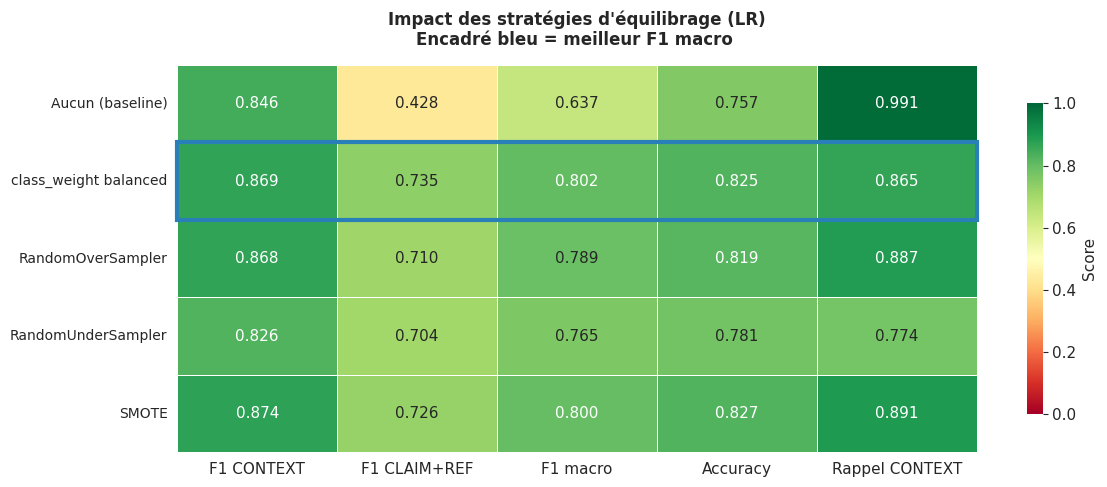


Analyse de la heatmap :
- Sans équilibrage : F1 CONTEXT = 0.000 le modèle ignore complètement CONTEXT
- class_weight='balanced' : correction simple, ajuste les poids dans la fonction du coût sans modifié les donées, donc on évit le overfitting.
- RandomOverSampler : duplique les CONTEXT ->risque d'overfitting sur ces 33 exemples
- RandomUnderSampler : supprime des CLAIM+REF -> on perd de l'information utile
- SMOTE : crée des exemples CONTEXT SYNTHÉTIQUES entre les vrais 

 Meilleure stratégie : class_weight balanced (F1 macro = 0.802)



In [72]:
metrics_bal = ['F1 CONTEXT', 'F1 CLAIM+REF', 'F1 macro', 'Accuracy', 'Rappel CONTEXT']
hm_data = df_balance.set_index('Stratégie')[metrics_bal]

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(
    hm_data,
    annot=True, fmt='.3f',
    cmap='RdYlGn',
    vmin=0.0, vmax=1.0,
    linewidths=0.6, linecolor='white',
    cbar_kws={'label': 'Score', 'shrink': 0.8},
    ax=ax
)

# Encadrer la meilleure ligne selon F1 macro
best_bal_idx = df_balance['F1 macro'].idxmax()
ax.add_patch(plt.Rectangle(
    (0, best_bal_idx), len(metrics_bal), 1,
    fill=False, edgecolor='#2980b9', lw=3, clip_on=False
))

ax.set_title(
    'Impact des stratégies d\'équilibrage (LR)\n'
    'Encadré bleu = meilleur F1 macro ',
    fontsize=12, fontweight='bold', pad=14
)
ax.tick_params(axis='y', rotation=0, labelsize=10)
ax.set_xlabel('')
ax.set_ylabel('')

plt.tight_layout()
plt.show()

best_strat = df_balance.loc[best_bal_idx, 'Stratégie']

print(f"""
Analyse de la heatmap :
- Sans équilibrage : F1 CONTEXT = 0.000 le modèle ignore complètement CONTEXT
- class_weight='balanced' : correction simple, ajuste les poids dans la fonction du coût sans modifié les donées, donc on évit le overfitting.
- RandomOverSampler : duplique les CONTEXT ->risque d'overfitting sur ces 33 exemples
- RandomUnderSampler : supprime des CLAIM+REF -> on perd de l'information utile
- SMOTE : crée des exemples CONTEXT SYNTHÉTIQUES entre les vrais 

 Meilleure stratégie : {best_strat} (F1 macro = {df_balance.loc[best_bal_idx,'F1 macro']:.3f})
""")

## Analyse comparative de différents classifieurs

In [82]:
skf_t2 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

best_strat = 'balanced'

models = {
    "Logistic Regression": LogisticRegression(class_weight=best_strat, max_iter=1000),
    "SVM Linear": SVC(kernel='linear', class_weight=best_strat),
    "SVM RBF": SVC(kernel='rbf', class_weight=best_strat),
    "Random Forest": RandomForestClassifier(class_weight=best_strat, n_estimators=100, random_state=42),
    "Decision Tree": DecisionTreeClassifier(class_weight=best_strat, random_state=42),
    "Naive Bayes": MultinomialNB(),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}

results_models = []

for name, clf in models.items():
    pipe = Pipeline([
        ("tfidf", TfidfVectorizer(**TFIDF_T2)),
        ("clf",   clf)
    ])
    sc = cross_validate(
        pipe, X, y,
        cv=skf_t2,
        scoring={
            'f1_macro':      'f1_macro',
            'precision_mac': 'precision_macro',
            'recall_macro':  'recall_macro',
            'accuracy':      'accuracy'
        },
        n_jobs=-1,
        error_score='raise'
    )
    results_models.append({
        'Modèle':    name,
        'F1 macro':  sc['test_f1_macro'].mean(),
        'F1 std':    sc['test_f1_macro'].std(),
        'Précision': sc['test_precision_mac'].mean(),
        'Rappel':    sc['test_recall_macro'].mean(),
        'Accuracy':  sc['test_accuracy'].mean(),
    })

df_models_t2 = pd.DataFrame(results_models).sort_values('F1 macro', ascending=False).reset_index(drop=True)
print("Résultats CV stratifiée 5 folds :")
print(df_models_t2.to_string(index=False))

Résultats CV stratifiée 5 folds :
             Modèle  F1 macro   F1 std  Précision   Rappel  Accuracy
         SVM Linear  0.765472 0.020955   0.762967 0.769020  0.790351
Logistic Regression  0.764284 0.016535   0.760369 0.769778  0.787719
            SVM RBF  0.754305 0.018964   0.776733 0.743059  0.794737
      Random Forest  0.720402 0.022219   0.750508 0.709072  0.771930
      Decision Tree  0.701900 0.032068   0.699676 0.706850  0.732456
                KNN  0.680380 0.030688   0.684276 0.684340  0.712281
        Naive Bayes  0.665673 0.036456   0.830352 0.656157  0.768421


In [83]:
from sklearn.metrics import make_scorer

f1_context_scorer = make_scorer(f1_score, pos_label=0, zero_division=0)
f1_macro_scorer   = make_scorer(f1_score, average='macro', zero_division=0)

model_records_t2 = []

for name, clf in MODELS_T2:
    pipe = Pipeline([
        ("tfidf", TfidfVectorizer(**TFIDF_T2)),
        ("clf",   clf)
    ])
    f1_mac = cross_val_score(pipe, X, y, cv=skf_t2, scoring=f1_macro_scorer,   n_jobs=-1)
    f1_ctx = cross_val_score(pipe, X, y, cv=skf_t2, scoring=f1_context_scorer, n_jobs=-1)
    acc    = cross_val_score(pipe, X, y, cv=skf_t2, scoring='accuracy',         n_jobs=-1)

    model_records_t2.append({
        'Modèle':        name,
        'F1 macro':      f1_mac.mean(),
        'F1 macro std':  f1_mac.std(),
        'F1 CONTEXT':    f1_ctx.mean(),
        'Accuracy':      acc.mean(),
    })
    print(f"{name:<28} F1_macro={f1_mac.mean():.3f}±{f1_mac.std():.3f}  F1_CONTEXT={f1_ctx.mean():.3f}")

df_models_t2 = pd.DataFrame(model_records_t2).sort_values('F1 macro', ascending=False).reset_index(drop=True)

SVM linear (baseline)        F1_macro=0.753±0.014  F1_CONTEXT=0.857
SVM linear (balanced)        F1_macro=0.765±0.021  F1_CONTEXT=0.842
SVM RBF (balanced)           F1_macro=0.754±0.019  F1_CONTEXT=0.854
LR (balanced)                F1_macro=0.764±0.017  F1_CONTEXT=0.839
Random Forest                F1_macro=0.722±0.028  F1_CONTEXT=0.842
Decision Tree                F1_macro=0.702±0.032  F1_CONTEXT=0.797
Naive Bayes                  F1_macro=0.666±0.036  F1_CONTEXT=0.851


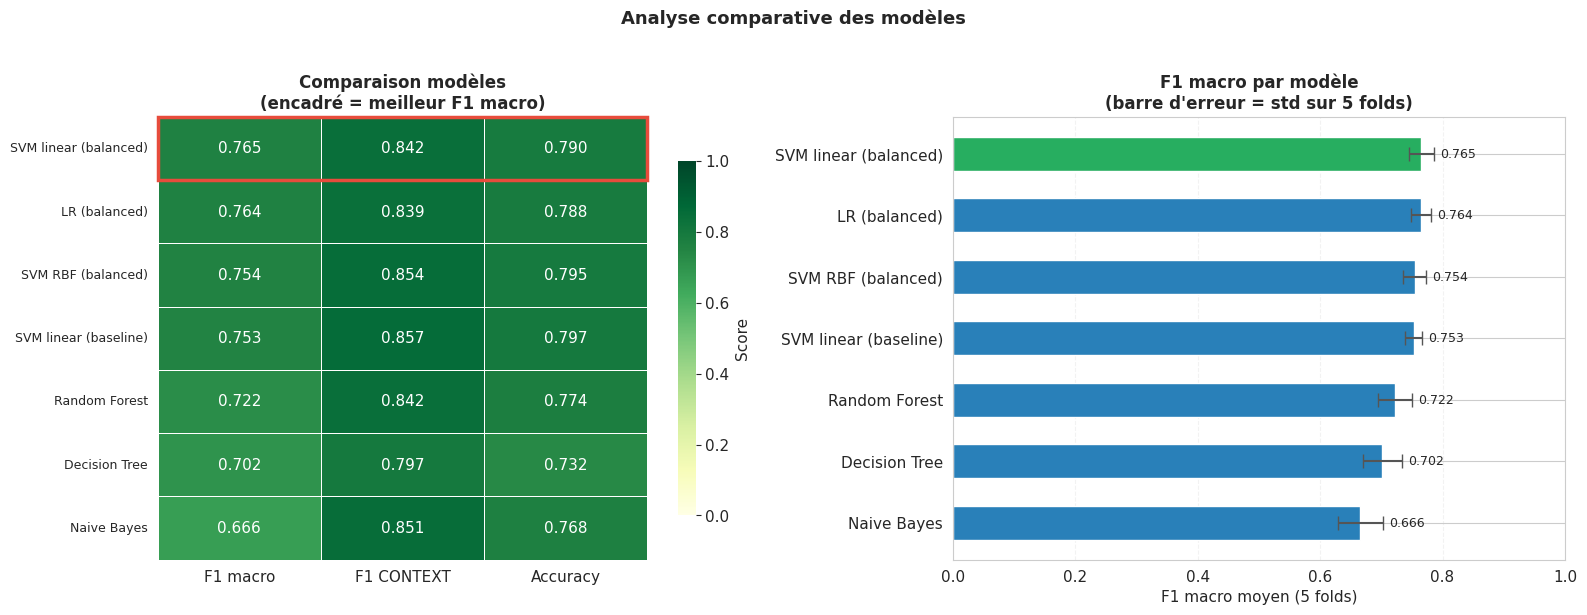


Lecture :
- Le F1 CONTEXT est la métrique clé ici (classe minoritaire à 8.8%)
- SVM baseline : F1 CONTEXT almost 0
- Meilleur modèle : SVM linear (balanced) (F1 macro = 0.765)
- La colonne Accuracy est trompeuse : même un modèle qui prédit TOUJOURS
  CLAIM+REF obtient 91.2% d'accuracy !



In [84]:
metrics_m = ['F1 macro', 'F1 CONTEXT', 'Accuracy']
hm_models = df_models_t2.set_index('Modèle')[metrics_m]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap 
sns.heatmap(
    hm_models,
    annot=True, fmt='.3f',
    cmap='YlGn',
    vmin=0.0, vmax=1.0,
    linewidths=0.5, linecolor='white',
    cbar_kws={'label': 'Score', 'shrink': 0.8},
    ax=axes[0]
)
best_row_t2 = df_models_t2['F1 macro'].idxmax()
axes[0].add_patch(plt.Rectangle(
    (0, best_row_t2), 3, 1,
    fill=False, edgecolor='#e74c3c', lw=2.5, clip_on=False
))
axes[0].set_title('Comparaison modèles\n(encadré = meilleur F1 macro)',
                   fontweight='bold', fontsize=12)
axes[0].tick_params(axis='y', rotation=0, labelsize=9)
axes[0].set_ylabel('')

# -- Bar chart F1 macro avec std --
palette_t2 = ['#27ae60' if i == 0 else '#2980b9' for i in range(len(df_models_t2))]
bars = axes[1].barh(
    df_models_t2['Modèle'][::-1],
    df_models_t2['F1 macro'][::-1],
    xerr=df_models_t2['F1 macro std'][::-1],
    color=palette_t2[::-1],
    edgecolor='white', capsize=5, height=0.55,
    error_kw={'elinewidth': 1.5, 'ecolor': '#555'}
)
for bar, (_, row) in zip(bars, df_models_t2[::-1].iterrows()):
    axes[1].text(
        row['F1 macro'] + row['F1 macro std'] + 0.01,
        bar.get_y() + bar.get_height()/2,
        f"{row['F1 macro']:.3f}",
        va='center', fontsize=9
    )
axes[1].set_xlim(0, 1.0)
axes[1].set_xlabel('F1 macro moyen (5 folds)', fontsize=11)
axes[1].set_title('F1 macro par modèle\n(barre d\'erreur = std sur 5 folds)',
                   fontweight='bold', fontsize=12)
axes[1].grid(axis='x', alpha=0.25, linestyle='--')

plt.suptitle('Analyse comparative des modèles',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

best_m = df_models_t2.iloc[0]
print(f"""
Lecture :
- Le F1 CONTEXT est la métrique clé ici (classe minoritaire à 8.8%)
- SVM baseline : F1 CONTEXT almost 0
- Meilleur modèle : {best_m['Modèle']} (F1 macro = {best_m['F1 macro']:.3f})
- La colonne Accuracy est trompeuse : même un modèle qui prédit TOUJOURS
  CLAIM+REF obtient 91.2% d'accuracy !
""")

**SVM et LR sont les meilleurs modèles**

## Features Discriminantes

In [89]:
from sklearn.feature_selection import chi2


# entraînement sur tout le corpus pour extraction des features
vec_bonus_t2 = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=5000,
    min_df=2, max_df=0.9,
    token_pattern=r'\b(?!http)\w{3,}\b'
)
X_bonus_t2 = vec_bonus_t2.fit_transform(X)
y_bonus_t2  = y
feat_names_t2 = np.array(vec_bonus_t2.get_feature_names_out())

# LR balanced sur tout le corpus
lr_bonus_t2 = LogisticRegression(class_weight='balanced', max_iter=1000)
lr_bonus_t2.fit(X_bonus_t2, y_bonus_t2)
coefs_t2 = lr_bonus_t2.coef_[0]

TOP = 20

# Top CONTEXT (coefs négatifs = classe 0)
top_context_idx  = coefs_t2.argsort()[:TOP]
# Top CLAIM+REF (coefs positifs = classe 1)
top_claimref_idx = coefs_t2.argsort()[::-1][:TOP]

df_feat_context  = pd.DataFrame({'token': feat_names_t2[top_context_idx],
                                  'coef':  coefs_t2[top_context_idx]})
df_feat_claimref = pd.DataFrame({'token': feat_names_t2[top_claimref_idx],
                                  'coef':  coefs_t2[top_claimref_idx]})

# Chi²
chi2_scores_t2, _ = chi2(X_bonus_t2, y_bonus_t2)
top_chi2_t2 = chi2_scores_t2.argsort()[::-1][:TOP]
df_chi2_t2  = pd.DataFrame({'token': feat_names_t2[top_chi2_t2],
                              'chi2':  chi2_scores_t2[top_chi2_t2]})

print("Top 20 features → CONTEXT (coefs LR négatifs) :")
print(df_feat_context.to_string(index=False))
print()
print("Top 20 features → CLAIM+REF (coefs LR positifs) :")
print(df_feat_claimref.to_string(index=False))
print()
print("Top 20 features discriminantes (Chi²) :")
print(df_chi2_t2.to_string(index=False))

Top 20 features → CONTEXT (coefs LR négatifs) :
      token      coef
       stop -4.230282
    support -3.076857
    reports -2.312486
      treat -1.165441
    promote -1.088674
       just -1.041548
     please -1.040881
       need -1.037353
        all -1.024480
        get -1.014894
      trump -0.980906
       news -0.891828
       game -0.853609
   stop the -0.816356
      stops -0.800433
   engineer -0.800281
     should -0.779222
      thing -0.772410
   supports -0.752753
support for -0.731006

Top 20 features → CLAIM+REF (coefs LR positifs) :
     token     coef
     study 2.031100
  research 1.957876
    health 1.935771
    cancer 1.697944
       can 1.675660
 eurekamag 1.543753
      risk 1.162146
   climate 1.151276
     brain 1.146508
      drug 1.057896
       men 1.028804
       how 0.999228
 infection 0.970778
   poverty 0.946743
scientists 0.928450
       non 0.890430
       and 0.888796
     blood 0.860850
      help 0.828299
 treatment 0.820462

Top 20 features di

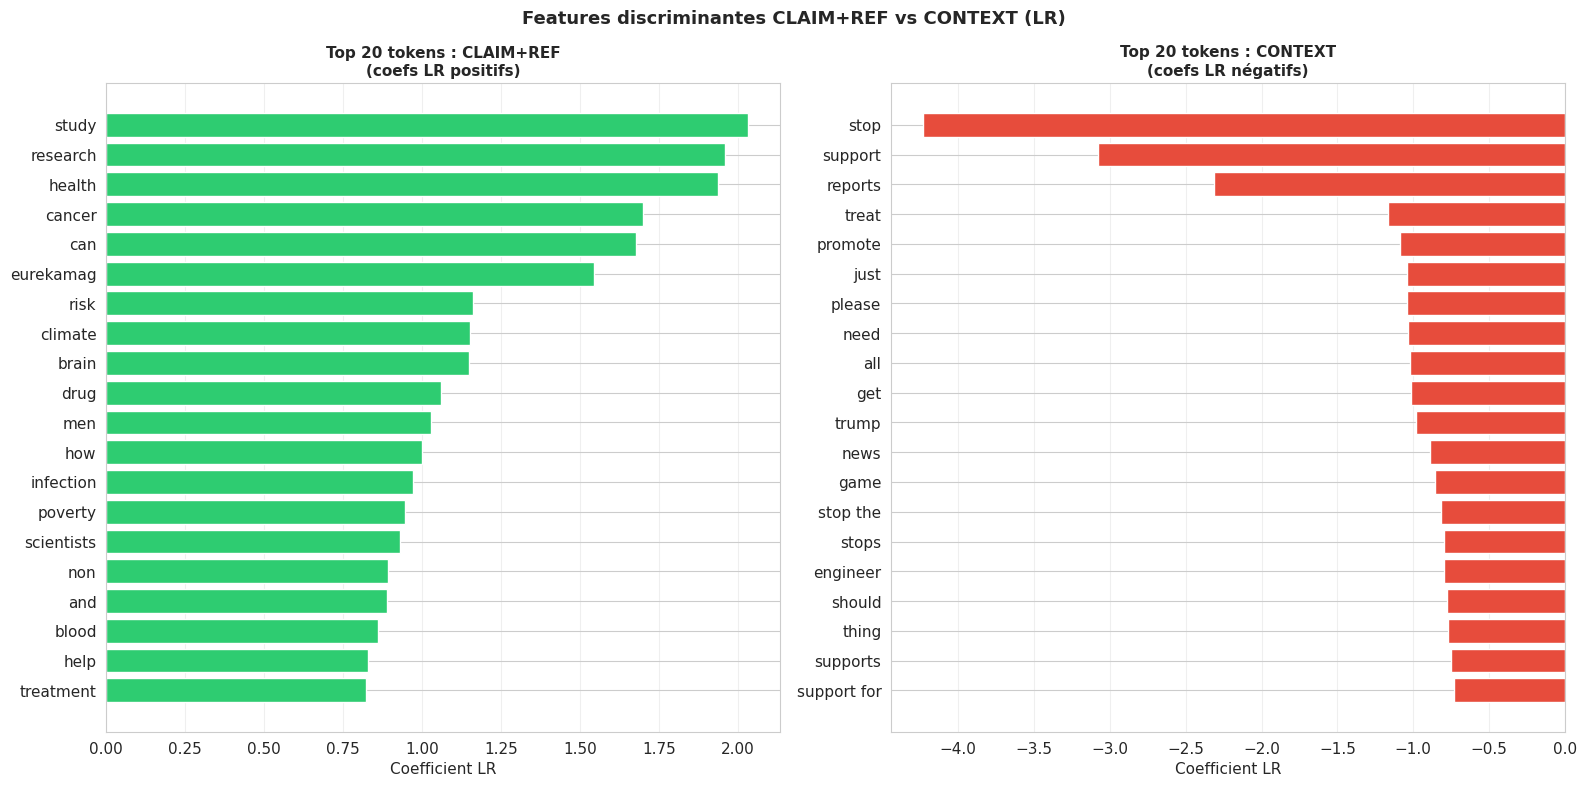

In [92]:
# ------------------------------------------------------------------
# Visualisation : double bar chart CONTEXT vs CLAIM+REF
# ------------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# CLAIM+REF
axes[0].barh(df_feat_claimref['token'][::-1], df_feat_claimref['coef'][::-1],
              color='#2ecc71', edgecolor='white')
axes[0].set_title(f'Top {TOP} tokens : CLAIM+REF\n(coefs LR positifs)',
                   fontweight='bold', fontsize=11)
axes[0].set_xlabel('Coefficient LR')
axes[0].grid(axis='x', alpha=0.3)

# CONTEXT
axes[1].barh(df_feat_context['token'][::-1], df_feat_context['coef'][::-1],
              color='#e74c3c', edgecolor='white')
axes[1].set_title(f'Top {TOP} tokens : CONTEXT\n(coefs LR négatifs)',
                   fontweight='bold', fontsize=11)
axes[1].set_xlabel('Coefficient LR')
axes[1].grid(axis='x', alpha=0.3)

plt.suptitle('Features discriminantes CLAIM+REF vs CONTEXT (LR)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Optimisation avec Optuna

In [95]:
from imblearn.pipeline import Pipeline as ImbPipeline

def objective_t2(trial):
    max_features  = trial.suggest_int("max_features", 500, 4000, step=500)
    min_df        = trial.suggest_int("min_df", 1, 4)
    ngram_max     = trial.suggest_categorical("ngram_max", [1, 2])
    C             = trial.suggest_float("C", 0.01, 10, log=True)
    balance_strat = trial.suggest_categorical(
        "balance", ["class_weight", "oversample", "smote"]
    )

    tfidf = TfidfVectorizer(
        ngram_range=(1, ngram_max),
        max_features=max_features,
        min_df=min_df,
        max_df=0.9,
        token_pattern=r'\b(?!http)\w{3,}\b'
    )

    cw = 'balanced' if balance_strat == 'class_weight' else None
    clf = LogisticRegression(C=C, class_weight=cw, max_iter=1000)

    if balance_strat in ['oversample', 'smote']:
        sampler = SMOTE(random_state=42, k_neighbors=4) if balance_strat == 'smote' \
                  else RandomOverSampler(random_state=42)
        pipe = ImbPipeline([("tfidf", tfidf), ("sampler", sampler), ("clf", clf)])
    else:
        pipe = Pipeline([("tfidf", tfidf), ("clf", clf)])

    scores = cross_val_score(
        pipe, X, y,
        cv=StratifiedKFold(5, shuffle=True, random_state=42),
        scoring=make_scorer(f1_score, average='macro', zero_division=0),
        n_jobs=-1
    )
    return scores.mean()

study_t2 = optuna.create_study(direction="maximize")
study_t2.optimize(objective_t2, n_trials=60, show_progress_bar=False)

print("Meilleur F1 macro Optuna T2 :", round(study_t2.best_value, 4))
print("Meilleurs hyperparamètres :")
for k, v in study_t2.best_params.items():
    print(f"  {k}: {v}")

[I 2026-05-13 23:40:24,367] A new study created in memory with name: no-name-878a7c43-1ee2-4608-aa09-f65ab67abfa7
[I 2026-05-13 23:40:25,089] Trial 0 finished with value: 0.7668133373390148 and parameters: {'max_features': 2500, 'min_df': 2, 'ngram_max': 2, 'C': 1.1540244183230535, 'balance': 'class_weight'}. Best is trial 0 with value: 0.7668133373390148.
[I 2026-05-13 23:40:25,601] Trial 1 finished with value: 0.7462890505593455 and parameters: {'max_features': 1500, 'min_df': 4, 'ngram_max': 1, 'C': 0.9503684114408452, 'balance': 'class_weight'}. Best is trial 0 with value: 0.7668133373390148.
[I 2026-05-13 23:40:26,235] Trial 2 finished with value: 0.7634527130336262 and parameters: {'max_features': 2500, 'min_df': 2, 'ngram_max': 2, 'C': 9.14120962013538, 'balance': 'oversample'}. Best is trial 0 with value: 0.7668133373390148.
[I 2026-05-13 23:40:26,789] Trial 3 finished with value: 0.7344580978097334 and parameters: {'max_features': 1000, 'min_df': 4, 'ngram_max': 2, 'C': 0.0899

Meilleur F1 macro Optuna T2 : 0.7748
Meilleurs hyperparamètres :
  max_features: 2000
  min_df: 1
  ngram_max: 1
  C: 1.4722069583919069
  balance: class_weight


In [96]:
bp = study_t2.best_params

tfidf_final_t2 = TfidfVectorizer(
    ngram_range=(1, bp['ngram_max']),
    max_features=bp['max_features'],
    min_df=bp['min_df'],
    max_df=0.9,
    token_pattern=r'\b(?!http)\w{3,}\b'
)

cw_final = 'balanced' if bp['balance'] == 'class_weight' else None
clf_final_t2 = LogisticRegression(C=bp['C'], class_weight=cw_final, max_iter=1000)

# Train sur le jeu d'entraînement stratifié
X_train_f = tfidf_final_t2.fit_transform(X_train)
X_test_f  = tfidf_final_t2.transform(X_test)

if bp['balance'] in ['oversample', 'smote']:
    sampler_f = SMOTE(random_state=42, k_neighbors=4) if bp['balance'] == 'smote' \
                else RandomOverSampler(random_state=42)
    X_train_f_res, y_train_res = sampler_f.fit_resample(X_train_f, y_train)
else:
    X_train_f_res, y_train_res = X_train_f, y_train

clf_final_t2.fit(X_train_f_res, y_train_res)
y_pred_final = clf_final_t2.predict(X_test_f)

print("=== Pipeline final T2 (Optuna) ===")
print(f"Stratégie d'équilibrage : {bp['balance']}")
print()
print(classification_report(y_test, y_pred_final,
                             target_names=['CONTEXT (0)', 'CLAIM+REF (1)'],
                             zero_division=0))

=== Pipeline final T2 (Optuna) ===
Stratégie d'équilibrage : class_weight

               precision    recall  f1-score   support

  CONTEXT (0)       0.85      0.86      0.86       230
CLAIM+REF (1)       0.71      0.70      0.70       112

     accuracy                           0.81       342
    macro avg       0.78      0.78      0.78       342
 weighted avg       0.81      0.81      0.81       342



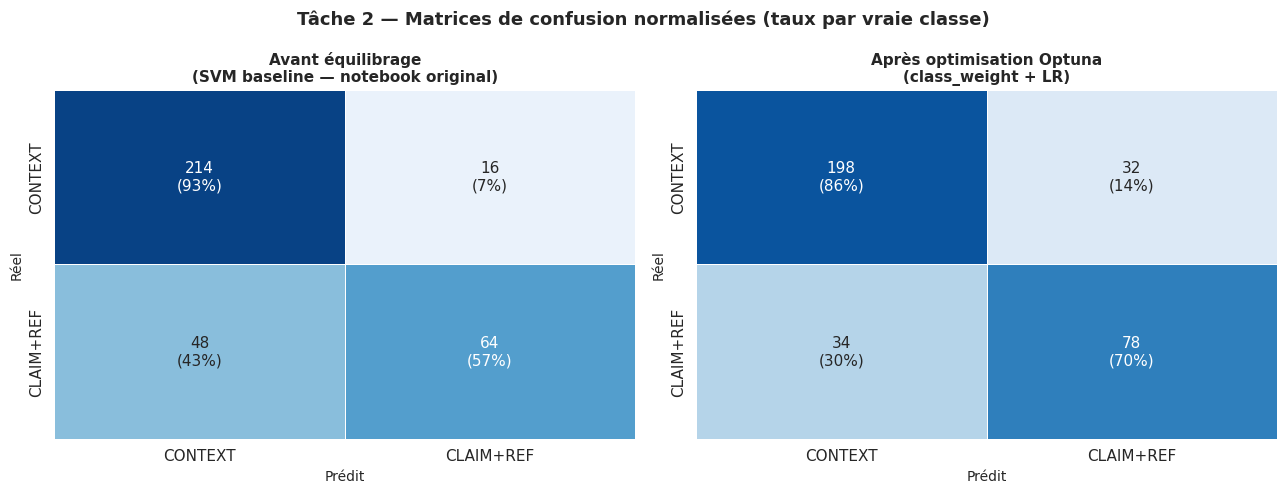


Comparaison avant / après :
  Avant : 214 CONTEXT bien classés sur 230 → rappel CONTEXT = 93%
  Après : 198  CONTEXT bien classés sur 230 → rappel CONTEXT = 86%

L'équilibrage améliore considérablement la détection de CONTEXT au prix
d'une légère augmentation des faux positifs (NON-SCI classés CONTEXT).



In [97]:
# Pipeline SANS équilibrage (comme dans le notebook original)
vec_base = TfidfVectorizer(**TFIDF_T2)
X_tr_base = vec_base.fit_transform(X_train)
X_te_base = vec_base.transform(X_test)
clf_base = SVC(kernel="linear")  # baseline du notebook original
clf_base.fit(X_tr_base, y_train)
y_pred_base = clf_base.predict(X_te_base)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, y_p, title in [
    (axes[0], y_pred_base,  'Avant équilibrage\n(SVM baseline — notebook original)'),
    (axes[1], y_pred_final, f'Après optimisation Optuna\n({bp["balance"]} + LR)'),
]:
    cm = confusion_matrix(y_test, y_p)
    cm_norm = confusion_matrix(y_test, y_p, normalize='true')

    # Annoter avec valeur absolue + %
    annot = np.array([
        [f"{cm[i,j]}\n({cm_norm[i,j]:.0%})" for j in range(2)]
        for i in range(2)
    ])

    sns.heatmap(
        cm_norm, annot=annot, fmt='', cmap='Blues',
        vmin=0, vmax=1,
        xticklabels=['CONTEXT', 'CLAIM+REF'],
        yticklabels=['CONTEXT', 'CLAIM+REF'],
        linewidths=0.5, linecolor='white',
        ax=ax, cbar=False
    )
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_xlabel('Prédit', fontsize=10)
    ax.set_ylabel('Réel', fontsize=10)

plt.suptitle(
    'Tâche 2 — Matrices de confusion normalisées (taux par vraie classe)',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()

cm_before = confusion_matrix(y_test, y_pred_base)
cm_after  = confusion_matrix(y_test, y_pred_final)

print(f"""
Comparaison avant / après :
  Avant : {cm_before[0,0]} CONTEXT bien classés sur {(y_test==0).sum()} → rappel CONTEXT = {cm_before[0,0]/(y_test==0).sum():.0%}
  Après : {cm_after[0,0]}  CONTEXT bien classés sur {(y_test==0).sum()} → rappel CONTEXT = {cm_after[0,0]/(y_test==0).sum():.0%}

L'équilibrage améliore considérablement la détection de CONTEXT au prix
d'une légère augmentation des faux positifs (NON-SCI classés CONTEXT).
""")

In [101]:
# Reconstruire le dataframe de test avec les textes bruts
df_test_t2 = pd.DataFrame({
    'text':   X_test.values,
    'y_true': y_test.values,
    'y_pred': y_pred_final,
})
df_test_t2['label_true'] = df_test_t2['y_true'].map({1: 'CLAIM+REF', 0: 'CONTEXT'})
df_test_t2['label_pred'] = df_test_t2['y_pred'].map({1: 'CLAIM+REF', 0: 'CONTEXT'})
df_test_t2['erreur']     = df_test_t2['y_true'] != df_test_t2['y_pred']

# Scores de décision (distance au seuil)
scores_dec = clf_final_t2.decision_function(X_test_f)
df_test_t2['score'] = scores_dec

fn_t2 = df_test_t2[(df_test_t2['y_true'] == 0) & (df_test_t2['y_pred'] == 1)]  # CONTEXT → CLAIM+REF
fp_t2 = df_test_t2[(df_test_t2['y_true'] == 1) & (df_test_t2['y_pred'] == 0)]  # CLAIM+REF → CONTEXT

print(f"CONTEXT dans le test : {(y_test==0).sum()}")
print(f"Faux négatifs (CONTEXT classés CLAIM+REF) : {len(fn_t2)}")
print(f"Faux positifs (CLAIM+REF classés CONTEXT) : {len(fp_t2)}")
print()

print('=' * 80)
print('FAUX NÉGATIFS : tweets CONTEXT que le modèle a classés CLAIM+REF')
print('Ces tweets parlent de recherche scientifique sans faire de claim ni citer')
print('ils sont ambigus par nature (ex : tweet qui mentionne une étude sans affirmer')
print('=' * 80)
for i, (_, row) in enumerate(fn_t2.sort_values('score', ascending=False).iterrows(), 1):
    print(f"\n[FN {i}] Score = {row['score']:.3f}")
    print(f"  Texte : {row['text'][:400]}")

print()
print('=' * 80)
print('FAUX POSITIFS : tweets CLAIM+REF classés CONTEXT')
print('Ces tweets font une affirmation ou citent une source mais sont classés CONTEXT')
print('=' * 80)
for i, (_, row) in enumerate(fp_t2.sort_values('score').head(8).iterrows(), 1):
    print(f"\n[FP {i}] Score = {row['score']:.3f}")
    print(f"  Texte : {row['text'][:400]}")

CONTEXT dans le test : 230
Faux négatifs (CONTEXT classés CLAIM+REF) : 32
Faux positifs (CLAIM+REF classés CONTEXT) : 34

FAUX NÉGATIFS : tweets CONTEXT que le modèle a classés CLAIM+REF
Ces tweets parlent de recherche scientifique sans faire de claim ni citer
ils sont ambigus par nature (ex : tweet qui mentionne une étude sans affirmer

[FN 1] Score = 1.008
  Texte : In 2018, Turkey is aiming to welcome 700,000 people to Troy in a bid to significantly increase the number of people disappointed by the historical site. https://t.co/HmvA8sOxzh

[FN 2] Score = 0.806
  Texte : @thebaqo @chiblkmn1 @shart_objects Facts! and with his scientist sister ooh. and the superpowers... idk man tho. Batman is a better strategist and fighter technique-wise. it's tough.

[FN 3] Score = 0.775
  Texte : #WeightLoss #Program Conquering The Excess Weight Of Diet Program Failure Statistics http://t.co/1d3No26Zz7 #LadyGaga #Diet

[FN 4] Score = 0.742
  Texte : @Bleah_Bleah @rickkenig @Chameleon_X_ @REV_20_10 

# Tâche 3 : Classification CLAIM vs REF vs CONTEXT 

In [159]:
#comme on n'a pas de pur 'ref' dans notre dataset , on a crée une 'priorité' REF>CLAIM>CONTEXT 
df_sci["target"] = df_sci["sublabel"].apply(
    lambda x: 1 if "REF" in x else (
        2 if "CLAIM" in x else 0
    )
)
print(df_sci["target"])
print(df_sci["text"])
counts = df_sci["target"].value_counts()
print(counts)


2       2
3       2
4       2
6       1
7       2
       ..
1128    1
1130    0
1131    0
1134    1
1135    2
Name: target, Length: 375, dtype: int64
2       Can any Gynecologist with Cancer Experience ex...
3       Couch-lock highs lead to sleeping in the couch...
4       Does daily routine help prevent problems with ...
6       “Traffic Jam” In Brain’s Neurons Could Be Caus...
7       Can playing more games improve lives and save ...
                              ...                        
1128    Three systematic reviews & the WHO contradict ...
1130    This looks like a great opportunity to get res...
1131    Highly prestigious and competitive awards fund...
1134    Vestislav Apostolov, David M. J. Calderbank, E...
1135    @LaylaFanucci @realDonaldTrump I'm sorry but w...
Name: text, Length: 375, dtype: object
target
1    203
2    139
0     33
Name: count, dtype: int64


In [160]:
#on peut remarquer qu'on n'a pas assez de 'CONTEXT' 33 vs 139 et 203 

In [161]:
pipeline = Pipeline([
    ("vectorizer", TfidfVectorizer(
        ngram_range=(1, 2),
        preprocessor= preprocess, 
        #stop_words='english',
        max_features=2000,
        token_pattern=r'\b(?!http)\w{3,}\b',
        min_df=3,
        max_df=0.8
    )),
    ("clf", SVC(kernel="linear")) #for now we are sticking t SVM but we'll compare with other classifiers
])

X = df_sci["text"]
y = df_sci["target"]


In [162]:
validation_size = 0.3 # 30 % du jeu de données pour le test
seed = 30
X_train, X_test, y_train, y_test = train_test_split(
X, y,
test_size=validation_size,
random_state=seed
)
print ("Format du jeu d'apprentissage : ",X_train.shape)
print ("Format du jeu de test :", X_test.shape)

Format du jeu d'apprentissage :  (262,)
Format du jeu de test : (113,)


In [163]:
pipeline.fit(X_train, y_train)
print("Accuracy:", pipeline.score(X_test, y_test))
y_pred = pipeline.predict(X_test)
conf = confusion_matrix(y_test, y_pred)
print("\nMatrice de confusion\n", conf)
print("\nClassification report\n",
classification_report(y_test, y_pred))

Accuracy: 0.5929203539823009

Matrice de confusion
 [[ 0  6  1]
 [ 0 51 18]
 [ 1 20 16]]

Classification report
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         7
           1       0.66      0.74      0.70        69
           2       0.46      0.43      0.44        37

    accuracy                           0.59       113
   macro avg       0.37      0.39      0.38       113
weighted avg       0.55      0.59      0.57       113



In [164]:
#visualising actual data 
results = pd.DataFrame({
    "tweet": X_test,
    "true_label": y_test,
    "predicted_label": y_pred
})

print(results.head(20))

                                                  tweet  true_label  \
1039  Durable, washable textile coating can repel vi...           1   
661   Optical Sensors Can Shed Light on Particle Dyn...           1   
600   Study finds increasing patient engagement can ...           1   
362   Bayes Theorem:What's the big deal? https://t.c...           1   
516   So what was Israels reason for attacks, murder...           2   
1071  New study emphasises the extraordinary degree ...           1   
466   Change is essential for growth, but if we’re n...           2   
83    Law leads to guilt,guilt leads to struggle,str...           2   
613   Why the definition of polycystic ovary syndrom...           1   
863   Corruption of Science Contributes to Collapse ...           1   
965   #ASH19 Paper No: 2723 Sun 1/7/19 6-8 PM #BPDCN...           1   
1069  @TexCIS @FoxNewsSunday 'Researchers found “no ...           1   
656       how u treat others will reflect on how u feel           2   
1053  

In [165]:
# normal results given it's better trained on 1 and 2
#resultat avec upsampling
#TF-IDF VECTORISATION 
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    ngram_range=(1,2),
    max_features=3000
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)
from imblearn.over_sampling import RandomOverSampler
from collections import Counter

print("Before:", Counter(y_train))

ros = RandomOverSampler(random_state=42)

X_train_res, y_train_res = ros.fit_resample(
    X_train_tfidf,
    y_train
)

print("After:", Counter(y_train_res))


Before: Counter({1: 134, 2: 102, 0: 26})
After: Counter({0: 134, 2: 134, 1: 134})


Accuracy: 0.6902654867256637


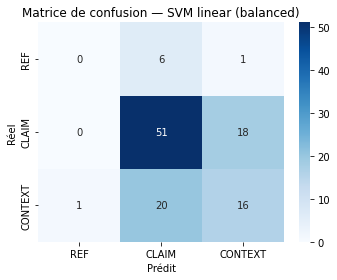

Classification Report:
               precision    recall  f1-score   support

           0       0.50      0.14      0.22         7
           1       0.70      0.87      0.77        69
           2       0.68      0.46      0.55        37

    accuracy                           0.69       113
   macro avg       0.63      0.49      0.51       113
weighted avg       0.68      0.69      0.67       113



In [166]:
clf = LogisticRegression(
    class_weight="balanced",
    max_iter=1000
)

clf.fit(X_train_res, y_train_res)

y_pred = clf.predict(X_test_tfidf)

print("Accuracy:", clf.score(X_test_tfidf, y_test))
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(conf, annot=True, fmt="d", cmap="Blues",
            xticklabels=["REF", "CLAIM", "CONTEXT"], yticklabels=["REF", "CLAIM", "CONTEXT"], ax=ax)
ax.set_xlabel("Prédit")
ax.set_ylabel("Réel")
ax.set_title("Matrice de confusion — SVM linear (balanced)")
plt.tight_layout()
plt.show()
print("Classification Report:\n", classification_report(y_test, y_pred))


In [167]:
#the recall and f1-score for class 0 is better but results not that much :'( 